<a href="https://colab.research.google.com/github/anh-tgmt/CV/blob/main/DATGMT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#BÀI TOÁN OBJECT DETECTION

#I, Cài đặt mô hình

In [ ]:
# Cài đặt thư viện
!pip install ultralytics -q

from ultralytics import YOLO
import os
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive


In [ ]:
import yaml

# Nội dung mới chuẩn cho Google Colab
data_configs = {
    'path': '/content/drive/MyDrive/TGMT/VOC2012', # Đường dẫn thực tế trên Drive của bạn
    'train': 'images/train',
    'val': 'images/val',
    'nc': 20,
    'names': {
        0: 'aeroplane', 1: 'bicycle', 2: 'bird', 3: 'boat', 4: 'bottle',
        5: 'bus', 6: 'car', 7: 'cat', 8: 'chair', 9: 'cow',
        10: 'diningtable', 11: 'dog', 12: 'horse', 13: 'motorbike',
        14: 'person', 15: 'pottedplant', 16: 'sheep', 17: 'sofa',
        18: 'train', 19: 'tvmonitor'
    }
}

# Đường dẫn đến file yaml trên Drive
yaml_path = '/content/drive/MyDrive/TGMT/VOC2012/dataset.yaml'

# Lệnh ghi đè (w = write)
with open(yaml_path, 'w') as f:
    yaml.dump(data_configs, f, default_flow_style=False)

print(f"✅ Đã đè thành công nội dung mới vào {yaml_path}")

✅ Đã đè thành công nội dung mới vào /content/drive/MyDrive/TGMT/VOC2012/dataset.yaml


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

# Đường dẫn nguồn trên Drive và đích trên SSD Colab
src_path = '/content/drive/MyDrive/TGMT/VOC2012'
dest_path = '/content/VOC2012'

# Copy dữ liệu từ Drive sang SSD (Sẽ mất vài phút tùy dung lượng)
if not os.path.exists(dest_path):
    print("🚀 Đang copy dữ liệu vào SSD Colab...")
    shutil.copytree(src_path, dest_path)
    print("✅ Đã copy xong!")

# Cập nhật lại file YAML để trỏ vào ổ SSD (/content/VOC2012)
import yaml
yaml_path = f'{dest_path}/dataset.yaml'
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['path'] = dest_path # Đổi path sang SSD
with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Đang copy dữ liệu vào SSD Colab...
✅ Đã copy xong!


#Tiền xử lý dữ liệu

In [ ]:
# ================================
# TIỀN XỬ LÝ DỮ LIỆU OBJECT DETECTION - VOC2012
# ================================

import os
import cv2
import glob
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Đường dẫn dữ liệu sau khi đã copy sang SSD Colab
DATA_PATH = '/content/VOC2012'
train_img_dir = os.path.join(DATA_PATH, 'images/train')
val_img_dir = os.path.join(DATA_PATH, 'images/val')
train_label_dir = os.path.join(DATA_PATH, 'labels/train')
val_label_dir = os.path.join(DATA_PATH, 'labels/val')

class_names = {
    0: 'aeroplane', 1: 'bicycle', 2: 'bird', 3: 'boat', 4: 'bottle',
    5: 'bus', 6: 'car', 7: 'cat', 8: 'chair', 9: 'cow',
    10: 'diningtable', 11: 'dog', 12: 'horse', 13: 'motorbike',
    14: 'person', 15: 'pottedplant', 16: 'sheep', 17: 'sofa',
    18: 'train', 19: 'tvmonitor'
}

# 1. Kiểm tra số lượng ảnh và nhãn
def count_files(img_dir, label_dir):
    images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    labels = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    return len(images), len(labels)

train_imgs, train_labels = count_files(train_img_dir, train_label_dir)
val_imgs, val_labels = count_files(val_img_dir, val_label_dir)

print("===== KIỂM TRA SỐ LƯỢNG DỮ LIỆU =====")
print(f"Train images: {train_imgs}")
print(f"Train labels: {train_labels}")
print(f"Val images  : {val_imgs}")
print(f"Val labels  : {val_labels}")

# 2. Kiểm tra ảnh không có nhãn
def check_missing_labels(img_dir, label_dir):
    missing = []
    for img_name in os.listdir(img_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            label_name = os.path.splitext(img_name)[0] + '.txt'
            label_path = os.path.join(label_dir, label_name)
            if not os.path.exists(label_path):
                missing.append(img_name)
    return missing

missing_train = check_missing_labels(train_img_dir, train_label_dir)
missing_val = check_missing_labels(val_img_dir, val_label_dir)

print("\n===== KIỂM TRA ẢNH THIẾU NHÃN =====")
print(f"Train thiếu nhãn: {len(missing_train)} ảnh")
print(f"Val thiếu nhãn  : {len(missing_val)} ảnh")

# 3. Kiểm tra nhãn sai định dạng hoặc class id ngoài khoảng 0-19
def check_invalid_labels(label_dir, max_class_id=19):
    invalid_files = []
    invalid_lines = []

    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            path = os.path.join(label_dir, label_file)
            with open(path, 'r') as f:
                lines = f.readlines()

            for idx, line in enumerate(lines):
                parts = line.strip().split()

                # YOLO detection format: class x_center y_center width height
                if len(parts) != 5:
                    invalid_files.append(label_file)
                    invalid_lines.append((label_file, idx + 1, line.strip()))
                    continue

                try:
                    cls_id = int(float(parts[0]))
                    values = list(map(float, parts[1:]))

                    if cls_id < 0 or cls_id > max_class_id:
                        invalid_files.append(label_file)
                        invalid_lines.append((label_file, idx + 1, line.strip()))

                    # Tọa độ YOLO phải nằm trong khoảng [0, 1]
                    if any(v < 0 or v > 1 for v in values):
                        invalid_files.append(label_file)
                        invalid_lines.append((label_file, idx + 1, line.strip()))

                except:
                    invalid_files.append(label_file)
                    invalid_lines.append((label_file, idx + 1, line.strip()))

    return list(set(invalid_files)), invalid_lines

invalid_train_files, invalid_train_lines = check_invalid_labels(train_label_dir, max_class_id=19)
invalid_val_files, invalid_val_lines = check_invalid_labels(val_label_dir, max_class_id=19)

print("\n===== KIỂM TRA NHÃN LỖI =====")
print(f"Train labels lỗi: {len(invalid_train_files)} file")
print(f"Val labels lỗi  : {len(invalid_val_files)} file")

# 4. Thống kê kích thước ảnh
def image_size_stats(img_dir):
    sizes = []

    for img_file in os.listdir(img_dir):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(img_dir, img_file)
            img = cv2.imread(img_path)

            if img is not None:
                h, w = img.shape[:2]
                sizes.append((w, h))

    return pd.DataFrame(sizes, columns=['width', 'height'])

df_train_size = image_size_stats(train_img_dir)
df_val_size = image_size_stats(val_img_dir)

print("\n===== THỐNG KÊ KÍCH THƯỚC ẢNH TRAIN =====")
print(df_train_size.describe())

print("\n===== THỐNG KÊ KÍCH THƯỚC ẢNH VAL =====")
print(df_val_size.describe())

===== KIỂM TRA SỐ LƯỢNG DỮ LIỆU =====
Train images: 5717
Train labels: 5717
Val images  : 5823
Val labels  : 5823

===== KIỂM TRA ẢNH THIẾU NHÃN =====
Train thiếu nhãn: 0 ảnh
Val thiếu nhãn  : 0 ảnh

===== KIỂM TRA NHÃN LỖI =====
Train labels lỗi: 0 file
Val labels lỗi  : 0 file

===== THỐNG KÊ KÍCH THƯỚC ẢNH TRAIN =====
             width       height
count  5717.000000  5717.000000
mean    471.680077   385.267973
std      57.976941    63.626330
min     142.000000   111.000000
25%     500.000000   335.000000
50%     500.000000   375.000000
75%     500.000000   377.000000
max     500.000000   500.000000

===== THỐNG KÊ KÍCH THƯỚC ẢNH VAL =====
             width       height
count  5823.000000  5823.000000
mean    469.445475   387.101838
std      60.023716    64.155000
min     182.000000    71.000000
25%     500.000000   335.000000
50%     500.000000   375.000000
75%     500.000000   382.000000
max     500.000000   500.000000


#Trực quan hóa dữ liệu

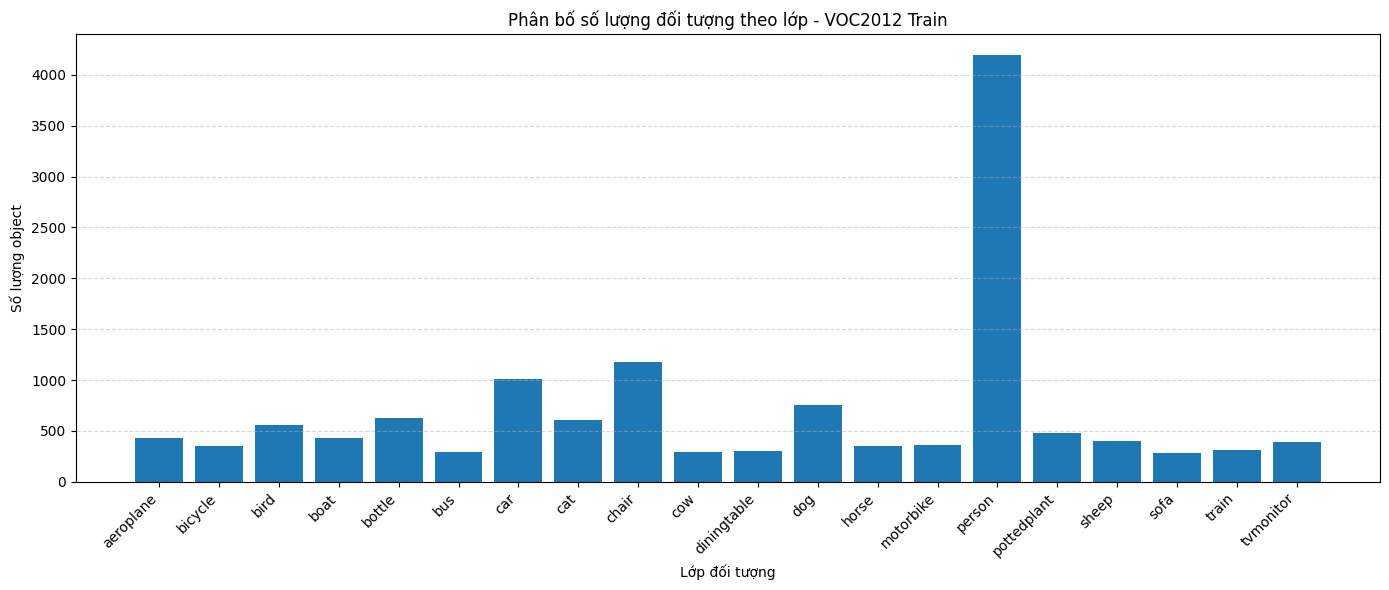

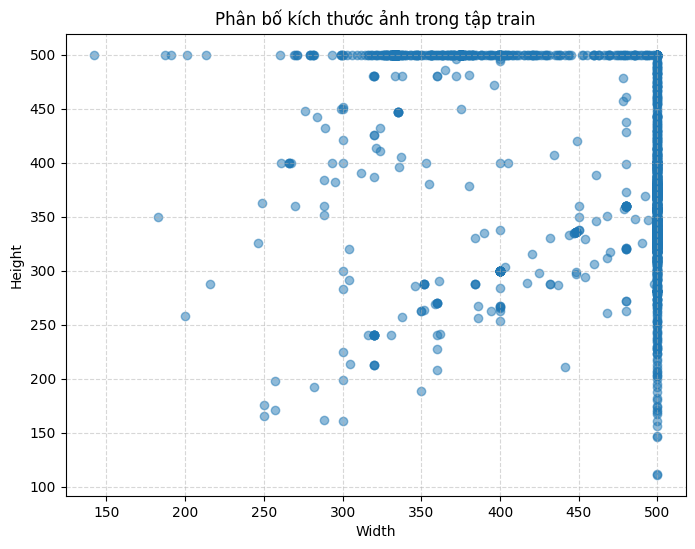

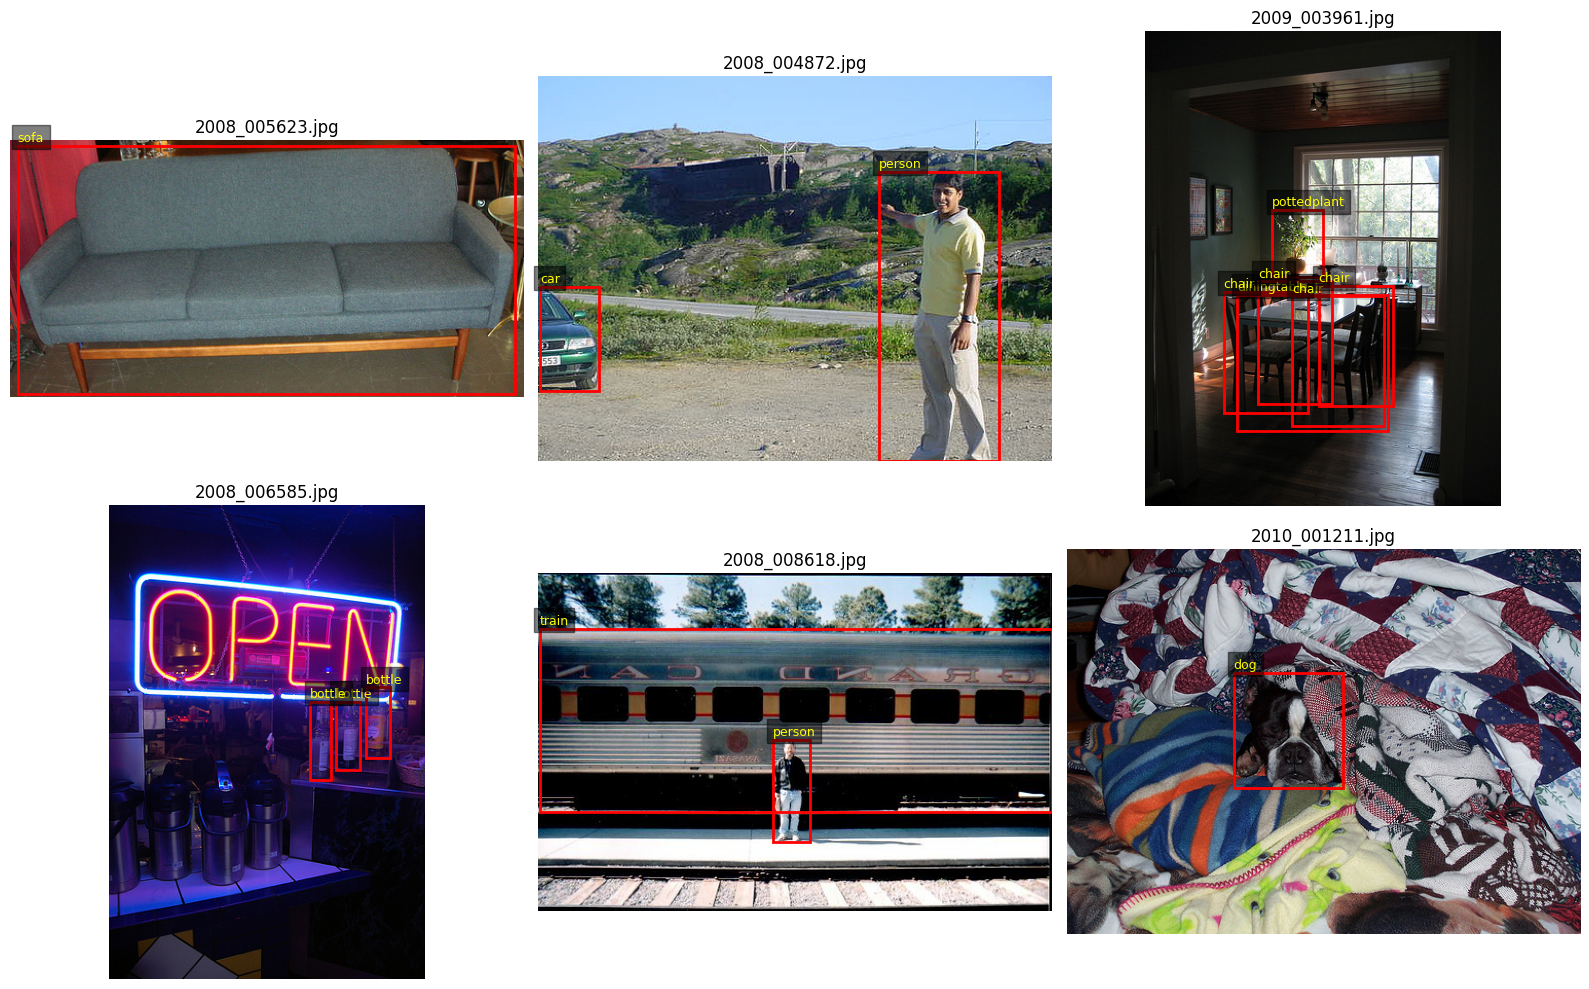

In [ ]:
# ================================
# TRỰC QUAN HÓA DỮ LIỆU OBJECT DETECTION
# ================================

import random
import matplotlib.patches as patches

# 1. Vẽ phân bố số lượng object theo class
def count_class_distribution(label_dir):
    counter = Counter()

    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            path = os.path.join(label_dir, label_file)

            with open(path, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 1:
                    try:
                        cls_id = int(float(parts[0]))
                        counter[cls_id] += 1
                    except:
                        pass

    return counter

train_counter = count_class_distribution(train_label_dir)

class_labels = [class_names[i] for i in sorted(train_counter.keys())]
class_counts = [train_counter[i] for i in sorted(train_counter.keys())]

plt.figure(figsize=(14, 6))
plt.bar(class_labels, class_counts)
plt.title('Phân bố số lượng đối tượng theo lớp - VOC2012 Train')
plt.xlabel('Lớp đối tượng')
plt.ylabel('Số lượng object')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Vẽ biểu đồ kích thước ảnh
plt.figure(figsize=(8, 6))
plt.scatter(df_train_size['width'], df_train_size['height'], alpha=0.5)
plt.title('Phân bố kích thước ảnh trong tập train')
plt.xlabel('Width')
plt.ylabel('Height')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Hiển thị ảnh mẫu kèm bounding box
def show_detection_samples(img_dir, label_dir, class_names, n=6):
    images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_images = random.sample(images, min(n, len(images)))

    plt.figure(figsize=(16, 10))

    for idx, img_name in enumerate(sample_images):
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + '.txt')

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        ax = plt.subplot(2, 3, idx + 1)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(img_name)

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()

                if len(parts) == 5:
                    cls_id, x_center, y_center, bw, bh = map(float, parts)
                    cls_id = int(cls_id)

                    x_center *= w
                    y_center *= h
                    bw *= w
                    bh *= h

                    x1 = x_center - bw / 2
                    y1 = y_center - bh / 2

                    rect = patches.Rectangle(
                        (x1, y1), bw, bh,
                        linewidth=2,
                        edgecolor='red',
                        facecolor='none'
                    )
                    ax.add_patch(rect)

                    ax.text(
                        x1, y1 - 5,
                        class_names.get(cls_id, str(cls_id)),
                        color='yellow',
                        fontsize=9,
                        bbox=dict(facecolor='black', alpha=0.5)
                    )

    plt.tight_layout()
    plt.show()

show_detection_samples(train_img_dir, train_label_dir, class_names, n=6)

#II, Khảo sát mô hình và train

In [ ]:
from ultralytics import YOLO

model_n = YOLO('yolov8n.pt')
model_n.train(
    data='/content/VOC2012/dataset.yaml',
    epochs=100, batch=32, imgsz=640, save_period=20,
    mosaic=1.0, mixup=0.2, lr0=0.01, freeze=10,
    project='/content/drive/MyDrive/TGMT/VOC2012/Runs', # Lưu thẳng về Drive
    name='Advanced_yolov8n',
    exist_ok=True
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/VOC2012/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Advanced_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

KeyboardInterrupt: 

In [ ]:
model_s = YOLO('yolov8s.pt')
model_s.train(
    data='/content/VOC2012/dataset.yaml',
    epochs=100, batch=32, imgsz=640, save_period=20,
    mosaic=1.0, mixup=0.2, lr0=0.01, freeze=10,
    project='/content/drive/MyDrive/TGMT/VOC2012/Runs',
    name='Advanced_yolov8s',
    exist_ok=True
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/VOC2012/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Advanced_yolov8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

In [ ]:
# Chọn checkpoint bạn muốn quay lại
checkpoint_path = '/content/drive/MyDrive/TGMT/VOC2012/Runs/Advanced_yolov8s/weights/epoch40.pt'

model = YOLO(checkpoint_path)

# Tiếp tục huấn luyện từ epoch 60 đến 100
model.train(resume=True)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/VOC2012/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/content/drive/MyDrive/TGMT/VOC2012/Runs/Advanced_yolov8s/weights/epoch40.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Advanced_yolov8s, nbs=64, nms=False, opset=None, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x784ee6f8d3d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043

In [ ]:
model_m = YOLO('yolov8m.pt')
model_m.train(
    data='/content/VOC2012/dataset.yaml',
    epochs=100, batch=32, imgsz=640, save_period=20,
    mosaic=1.0, mixup=0.2, lr0=0.01, freeze=10,
    project='/content/drive/MyDrive/TGMT/VOC2012/Runs',
    name='Advanced_yolov8m',
    exist_ok=True
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/VOC2012/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Advanced_yolov8m, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

In [ ]:
# Chọn checkpoint bạn muốn quay lại
checkpoint_path = '/content/drive/MyDrive/TGMT/VOC2012/Runs/Advanced_yolov8m/weights/epoch60.pt'

model = YOLO(checkpoint_path)

# Tiếp tục huấn luyện từ epoch 60 đến 100
model.train(resume=True)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/VOC2012/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/content/drive/MyDrive/TGMT/VOC2012/Runs/Advanced_yolov8m/weights/epoch60.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Advanced_yolov8m, nbs=64, nms=False, opset=None, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b46893d8860>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043

#III, So sánh

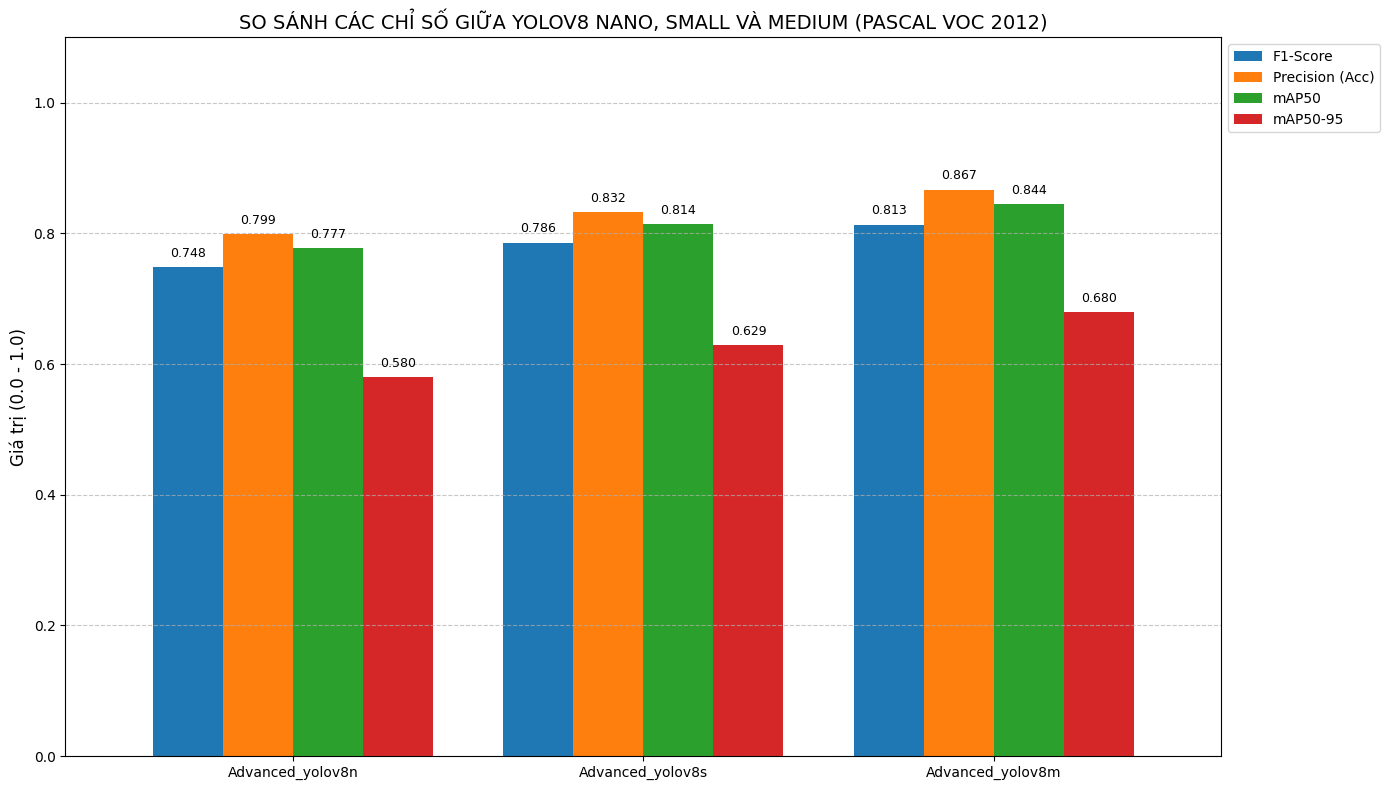


--- BẢNG THỐNG KÊ CHI TIẾT ---
                  F1-Score  Precision (Acc)   mAP50  mAP50-95
Advanced_yolov8n  0.748255          0.79886  0.7771   0.57983
Advanced_yolov8s  0.786025          0.83243  0.8139   0.62852
Advanced_yolov8m  0.813032          0.86687  0.8444   0.67955


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Đường dẫn đến thư mục Runs trên Drive
runs_dir = '/content/drive/MyDrive/TGMT/VOC2012/Runs'
models = ['Advanced_yolov8n', 'Advanced_yolov8s', 'Advanced_yolov8m']
metrics = ['metrics/precision(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']
# F1-score thường được tính bằng: 2 * (P * R) / (P + R)

results_summary = {}

for model_name in models:
    csv_path = os.path.join(runs_dir, model_name, 'results.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df.columns = [c.strip() for c in df.columns] # Xóa khoảng trắng thừa

        # Lấy dòng cuối cùng (epoch 100)
        final_row = df.iloc[-1]

        p = final_row['metrics/precision(B)']
        r = final_row['metrics/recall(B)']
        f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        results_summary[model_name] = {
            'F1-Score': f1,
            'Precision (Acc)': p,
            'mAP50': final_row['metrics/mAP50(B)'],
            'mAP50-95': final_row['metrics/mAP50-95(B)']
        }

# Chuyển sang DataFrame để vẽ đồ thị
df_plot = pd.DataFrame(results_summary).T

# Vẽ biểu đồ cột nhóm (Grouped Bar Chart)
ax = df_plot.plot(kind='bar', figsize=(14, 8), width=0.8)
plt.title('SO SÁNH CÁC CHỈ SỐ GIỮA YOLOV8 NANO, SMALL VÀ MEDIUM (PASCAL VOC 2012)', fontsize=14)
plt.ylabel('Giá trị (0.0 - 1.0)', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Thêm số liệu cụ thể lên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

# In bảng dữ liệu ra console
print("\n--- BẢNG THỐNG KÊ CHI TIẾT ---")
print(df_plot)

#IV, Kiểm thử với một video bất kì

In [ ]:
import cv2
import os
from ultralytics import YOLO
import torch

# 1. Đường dẫn
video_input_path = '/content/drive/MyDrive/TGMT/Test_Video/test.mp4'
output_path = '/content/drive/MyDrive/TGMT/Video_Results/TONG_CONG_DON_VIDEO.mp4'
weights = '/content/drive/MyDrive/TGMT/VOC2012/Runs/Advanced_yolov8m/weights/best.pt'

os.makedirs(os.path.dirname(output_path), exist_ok=True)

# 2. Load mô hình
model = YOLO(weights)
class_names = model.names
device = '0' if torch.cuda.is_available() else 'cpu'

# 3. Khởi tạo biến lưu trữ cộng dồn (Dùng set để lưu ID duy nhất)
cumulative_counts = {} # Cấu trúc: {class_name: set(id1, id2, ...)}

cap = cv2.VideoCapture(video_input_path)
width, height, fps = int(cap.get(3)), int(cap.get(4)), int(cap.get(5))
out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

print(f"🚀 Đang chạy Tracking để đếm cộng dồn toàn bộ video...")

while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    # SỬ DỤNG model.track ĐỂ CẤP ID CHO MỖI VẬT THỂ
    # persist=True giúp giữ ID giữa các khung hình
    results = model.track(frame, conf=0.3, imgsz=640, device=device, persist=True, verbose=False, tracker="botsort.yaml")

    annotated_frame = frame.copy()

    for r in results:
        if r.boxes.id is not None: # Chỉ xử lý nếu vật thể có ID
            boxes = r.boxes.xyxy.cpu().numpy()
            ids = r.boxes.id.int().cpu().numpy()
            clss = r.boxes.cls.int().cpu().numpy()
            confs = r.boxes.conf.cpu().numpy()

            for box, obj_id, cls_id, conf in zip(boxes, ids, clss, confs):
                label = class_names[cls_id]

                # CẬP NHẬT CỘNG DỒN
                if label not in cumulative_counts:
                    cumulative_counts[label] = set()
                cumulative_counts[label].add(obj_id) # Set sẽ tự loại bỏ ID trùng

                # Vẽ Box và ID lên màn hình
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                # Hiển thị ID để Đức Anh thấy nó đang theo dõi đúng vật đó
                cv2.putText(annotated_frame, f"ID:{obj_id} {label}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

        # --- BẢNG THỐNG KÊ CỘNG DỒN (Cập nhật liên tục đến cuối video) ---
        bg_h = 40 + (len(cumulative_counts) * 30)
        overlay = annotated_frame.copy()
        cv2.rectangle(overlay, (0, 0), (400, bg_h), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.7, annotated_frame, 0.3, 0, annotated_frame)

        cv2.putText(annotated_frame, "TONG CONG DON TOAN VIDEO:", (15, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        for i, (name, id_set) in enumerate(cumulative_counts.items()):
            y_pos = 60 + (i * 30)
            total_so_far = len(id_set)
            cv2.putText(annotated_frame, f"- {name.upper()}: {total_so_far} vat the", (20, y_pos),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    out.write(annotated_frame)

cap.release()
out.release()

print("-" * 30)
print("📊 TỔNG KẾT CUỐI VIDEO:")
for name, id_set in cumulative_counts.items():
    print(f"🔹 {name}: {len(id_set)} vật thể duy nhất.")
print(f"✅ Đã lưu video kết quả tại: {output_path}")

🚀 Đang chạy Tracking để đếm cộng dồn toàn bộ video...
------------------------------
📊 TỔNG KẾT CUỐI VIDEO:
🔹 person: 11 vật thể duy nhất.
🔹 car: 64 vật thể duy nhất.
🔹 train: 2 vật thể duy nhất.
🔹 bus: 10 vật thể duy nhất.
🔹 motorbike: 9 vật thể duy nhất.
🔹 boat: 1 vật thể duy nhất.
🔹 horse: 2 vật thể duy nhất.
🔹 sheep: 1 vật thể duy nhất.
✅ Đã lưu video kết quả tại: /content/drive/MyDrive/TGMT/Video_Results/TONG_CONG_DON_VIDEO.mp4


#BÀI TOÁN SEGMENTATION

#I, Cài đặt mask

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.makedirs('/content/dataset/images/train', exist_ok=True)
os.makedirs('/content/dataset/images/val', exist_ok=True)
os.makedirs('/content/dataset/labels/train', exist_ok=True)
os.makedirs('/content/dataset/labels/val', exist_ok=True)

In [ ]:
# Copy Ảnh (Thay đổi đường dẫn nguồn tương ứng với Drive của bạn)
!cp -r /content/drive/MyDrive/TGMT/Segmentation/data/images/* /content/dataset/images/

# Copy Nhãn (Labels)
!cp -r /content/drive/MyDrive/TGMT/Segmentation/data/labels/* /content/dataset/labels/

# Kiểm tra số lượng để chắc chắn không bị "cụt" dòng như lúc nãy
print("Số lượng ảnh Train:", len(os.listdir('/content/dataset/images/train')))
print("Số lượng nhãn Train:", len(os.listdir('/content/dataset/labels/train')))

Số lượng ảnh Train: 7000
Số lượng nhãn Train: 7000


In [ ]:
import yaml
import os

# 1. Định nghĩa cấu trúc dữ liệu
data_config = {
    # Đường dẫn gốc tới thư mục chứa data
    'path': '/content/drive/MyDrive/TGMT/Segmentation/data',

    # Đường dẫn tương đối từ 'path' đến thư mục ảnh
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test', # Có thể để trống nếu không có nhãn tập test

    # Danh sách các lớp (Classes) - Điều chỉnh theo dataset thực tế của bạn
    # BDD100K mặc định thường có các lớp sau cho Segmentation
    'names': {
      0: 'fence',
      1: 'pole',
      2: 'traffic light',
      3: 'traffic sign',
      4: 'person',
      5: 'rider',
      6: 'car',
      7: 'truck',
      8: 'bus',
      9: 'train',
      10: 'motorcycle',
      11: 'bicycle'
}
}

# 2. Đường dẫn lưu file yaml
yaml_file_path = '/content/drive/MyDrive/TGMT/Segmentation/bdd100k.yaml'

# Đảm bảo thư mục cha tồn tại
os.makedirs(os.path.dirname(yaml_file_path), exist_ok=True)

# 3. Ghi file
with open(yaml_file_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)

print(f"✅ Đã tạo file cấu hình tại: {yaml_file_path}")

# Hiển thị nội dung file để kiểm tra
with open(yaml_file_path, 'r') as f:
    print("\nNội dung file YAML:")
    print(f.read())

✅ Đã tạo file cấu hình tại: /content/drive/MyDrive/TGMT/Segmentation/bdd100k.yaml

Nội dung file YAML:
path: /content/drive/MyDrive/TGMT/Segmentation/data
train: images/train
val: images/val
test: images/test
names:
  0: fence
  1: pole
  2: traffic light
  3: traffic sign
  4: person
  5: rider
  6: car
  7: truck
  8: bus
  9: train
  10: motorcycle
  11: bicycle



In [ ]:
import yaml
import os

# 1. Định nghĩa cấu trúc cho SSD cục bộ
data_config = {
    # Đường dẫn gốc tới thư mục chứa data
    'path': '/content/dataset',

    # Đường dẫn tương đối từ 'path' đến thư mục ảnh
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test', # Có thể để trống nếu không có nhãn tập test

    # Danh sách các lớp (Classes) - Điều chỉnh theo dataset thực tế của bạn
    # BDD100K mặc định thường có các lớp sau cho Segmentation
    'names': {
      0: 'road',
    1: 'sidewalk',
    2: 'building',
    3: 'wall',
    4: 'fence',
    5: 'pole',
    6: 'traffic light',
    7: 'traffic sign',
    8: 'vegetation',
    9: 'terrain',
    10: 'sky',
    11: 'person',
    12: 'rider',
    13: 'car',
    14: 'truck',
    15: 'bus',
    16: 'train',
    17: 'motorcycle',
    18: 'bicycle'
}
}

# 2. Lưu file yaml vào thư mục /content/ để tiện sử dụng
yaml_path = '/content/bdd100k_local.yaml'

with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)

print(f"✅ Đã cập nhật file YAML tại: {yaml_path}")

# 3. Kiểm tra nhanh xem dữ liệu đã nằm đúng chỗ chưa
train_img_path = os.path.join(data_config['path'], data_config['train'])
if os.path.exists(train_img_path):
    print(f"📁 Kiểm tra: Thư mục ảnh train tồn tại ({len(os.listdir(train_img_path))} ảnh)")
else:
    print("❌ Cảnh báo: Không tìm thấy thư mục ảnh tại đường dẫn đã cấu hình!")

✅ Đã cập nhật file YAML tại: /content/bdd100k_local.yaml
📁 Kiểm tra: Thư mục ảnh train tồn tại (7000 ảnh)


#Tiền xử lý dữ liệu

In [ ]:
# ================================
# TIỀN XỬ LÝ DỮ LIỆU SEGMENTATION - BDD100K
# ================================

import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

SEG_DATA_PATH = '/content/dataset'
seg_train_img_dir = '/content/dataset/images/train'
seg_val_img_dir = '/content/dataset/images/val'
seg_train_label_dir = '/content/dataset/labels/train'
seg_val_label_dir = '/content/dataset/labels/val'

seg_class_names = {
    0: 'road',
    1: 'sidewalk',
    2: 'building',
    3: 'wall',
    4: 'fence',
    5: 'pole',
    6: 'traffic light',
    7: 'traffic sign',
    8: 'vegetation',
    9: 'terrain',
    10: 'sky',
    11: 'person',
    12: 'rider',
    13: 'car',
    14: 'truck',
    15: 'bus',
    16: 'train',
    17: 'motorcycle',
    18: 'bicycle'
}

# 1. Kiểm tra số lượng ảnh và nhãn
def count_seg_files(img_dir, label_dir):
    images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    labels = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    return len(images), len(labels)

train_img_count, train_label_count = count_seg_files(seg_train_img_dir, seg_train_label_dir)
val_img_count, val_label_count = count_seg_files(seg_val_img_dir, seg_val_label_dir)

print("===== KIỂM TRA SỐ LƯỢNG DỮ LIỆU SEGMENTATION =====")
print(f"Train images: {train_img_count}")
print(f"Train labels: {train_label_count}")
print(f"Val images  : {val_img_count}")
print(f"Val labels  : {val_label_count}")

# 2. Kiểm tra ảnh thiếu nhãn
def find_missing_seg_labels(img_dir, label_dir):
    missing = []

    for img_file in os.listdir(img_dir):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            label_file = os.path.splitext(img_file)[0] + '.txt'
            label_path = os.path.join(label_dir, label_file)

            if not os.path.exists(label_path):
                missing.append(img_file)

    return missing

missing_train_seg = find_missing_seg_labels(seg_train_img_dir, seg_train_label_dir)
missing_val_seg = find_missing_seg_labels(seg_val_img_dir, seg_val_label_dir)

print("\n===== KIỂM TRA ẢNH THIẾU LABEL =====")
print(f"Train thiếu label: {len(missing_train_seg)} ảnh")
print(f"Val thiếu label  : {len(missing_val_seg)} ảnh")

# 3. Kiểm tra label segmentation sai định dạng
# YOLO segmentation format:
# class x1 y1 x2 y2 x3 y3 ... xn yn
# Một dòng hợp lệ cần có class_id + ít nhất 3 điểm polygon = 1 + 6 số = 7 phần tử

def check_seg_label_format(label_dir, max_class_id=18):
    invalid_files = []
    invalid_lines = []

    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            label_path = os.path.join(label_dir, label_file)

            with open(label_path, 'r') as f:
                lines = f.readlines()

            for idx, line in enumerate(lines):
                parts = line.strip().split()

                if len(parts) < 7:
                    invalid_files.append(label_file)
                    invalid_lines.append((label_file, idx + 1, line.strip()))
                    continue

                # Sau class_id, số tọa độ phải là số chẵn
                if (len(parts) - 1) % 2 != 0:
                    invalid_files.append(label_file)
                    invalid_lines.append((label_file, idx + 1, line.strip()))
                    continue

                try:
                    cls_id = int(float(parts[0]))
                    coords = list(map(float, parts[1:]))

                    if cls_id < 0 or cls_id > max_class_id:
                        invalid_files.append(label_file)
                        invalid_lines.append((label_file, idx + 1, line.strip()))

                    if any(c < 0 or c > 1 for c in coords):
                        invalid_files.append(label_file)
                        invalid_lines.append((label_file, idx + 1, line.strip()))

                except:
                    invalid_files.append(label_file)
                    invalid_lines.append((label_file, idx + 1, line.strip()))

    return list(set(invalid_files)), invalid_lines

invalid_train_seg_files, invalid_train_seg_lines = check_seg_label_format(seg_train_label_dir)
invalid_val_seg_files, invalid_val_seg_lines = check_seg_label_format(seg_val_label_dir)

print("\n===== KIỂM TRA LABEL SEGMENTATION LỖI =====")
print(f"Train label lỗi: {len(invalid_train_seg_files)} file")
print(f"Val label lỗi  : {len(invalid_val_seg_files)} file")

# 4. Lọc ID class không hợp lệ, ví dụ class 255
def remove_invalid_seg_class_ids(label_dir, max_class_id=18):
    total_removed = 0
    total_files = 0

    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            path = os.path.join(label_dir, label_file)

            with open(path, 'r') as f:
                lines = f.readlines()

            valid_lines = []

            for line in lines:
                parts = line.strip().split()

                if len(parts) > 0:
                    try:
                        cls_id = int(float(parts[0]))

                        if 0 <= cls_id <= max_class_id:
                            valid_lines.append(line.strip())
                        else:
                            total_removed += 1

                    except:
                        total_removed += 1

            with open(path, 'w') as f:
                f.write('\n'.join(valid_lines))

            total_files += 1

    print(f"Đã xử lý {total_files} file trong {label_dir}")
    print(f"Số dòng label bị loại bỏ: {total_removed}")

remove_invalid_seg_class_ids(seg_train_label_dir, max_class_id=18)
remove_invalid_seg_class_ids(seg_val_label_dir, max_class_id=18)

# 5. Xóa cache cũ của YOLO để tránh đọc lại label lỗi
!rm -rf /content/dataset/labels/train.cache
!rm -rf /content/dataset/labels/val.cache
!rm -rf /content/dataset/*.cache

print("Đã xóa cache cũ của YOLO.")

===== KIỂM TRA SỐ LƯỢNG DỮ LIỆU SEGMENTATION =====
Train images: 7000
Train labels: 7000
Val images  : 1000
Val labels  : 1000

===== KIỂM TRA ẢNH THIẾU LABEL =====
Train thiếu label: 7000 ảnh
Val thiếu label  : 1000 ảnh

===== KIỂM TRA LABEL SEGMENTATION LỖI =====
Train label lỗi: 6977 file
Val label lỗi  : 1000 file
Đã xử lý 7000 file trong /content/dataset/labels/train
Số dòng label bị loại bỏ: 82567
Đã xử lý 1000 file trong /content/dataset/labels/val
Số dòng label bị loại bỏ: 18729
Đã xóa cache cũ của YOLO.


#Trực quan hóa dữ liệu

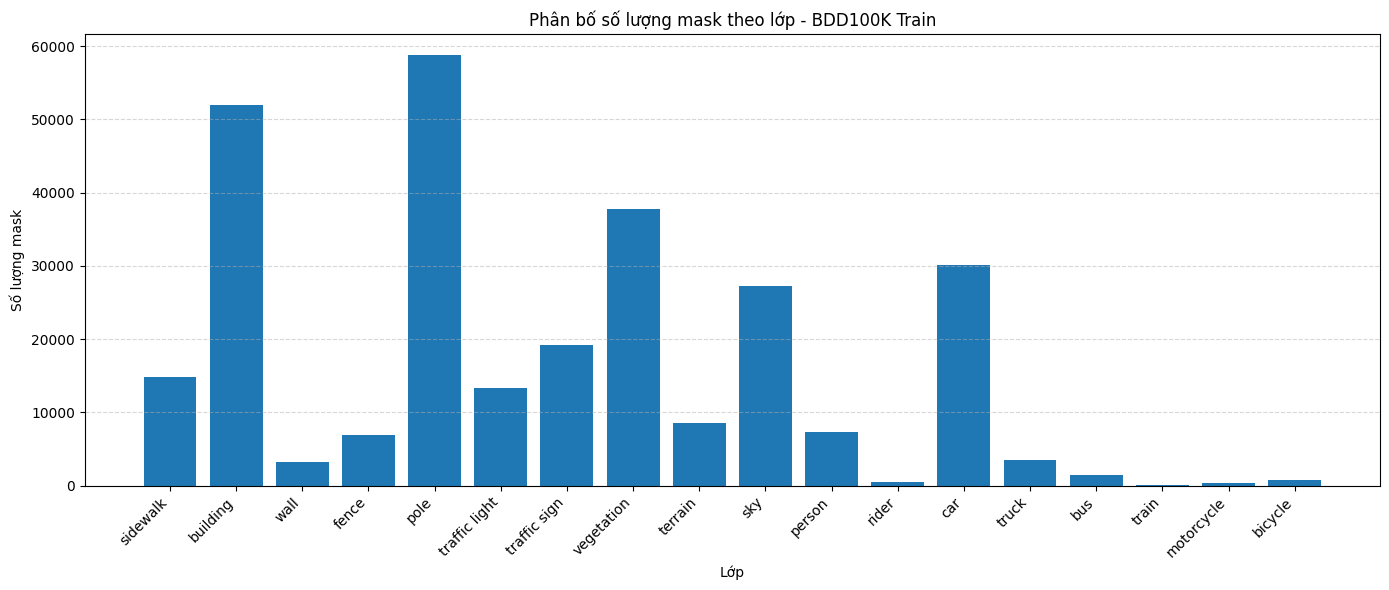

===== THỐNG KÊ SỐ MASK TRÊN MỖI ẢNH =====
count    7000.000000
mean       40.884286
std        22.529720
min         0.000000
25%        25.000000
50%        37.000000
75%        53.000000
max       185.000000
Name: num_masks, dtype: float64


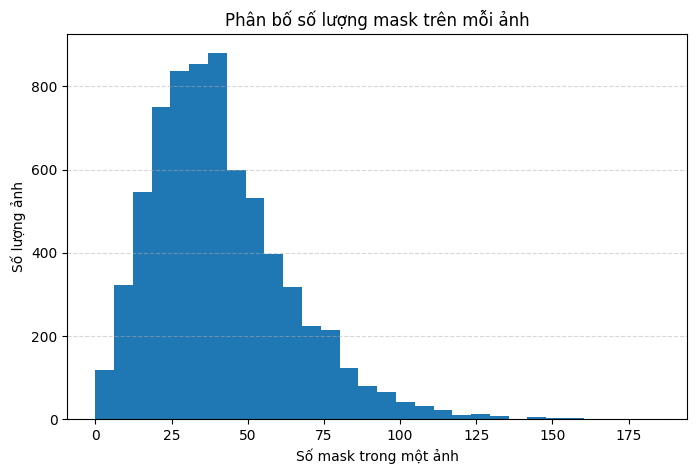

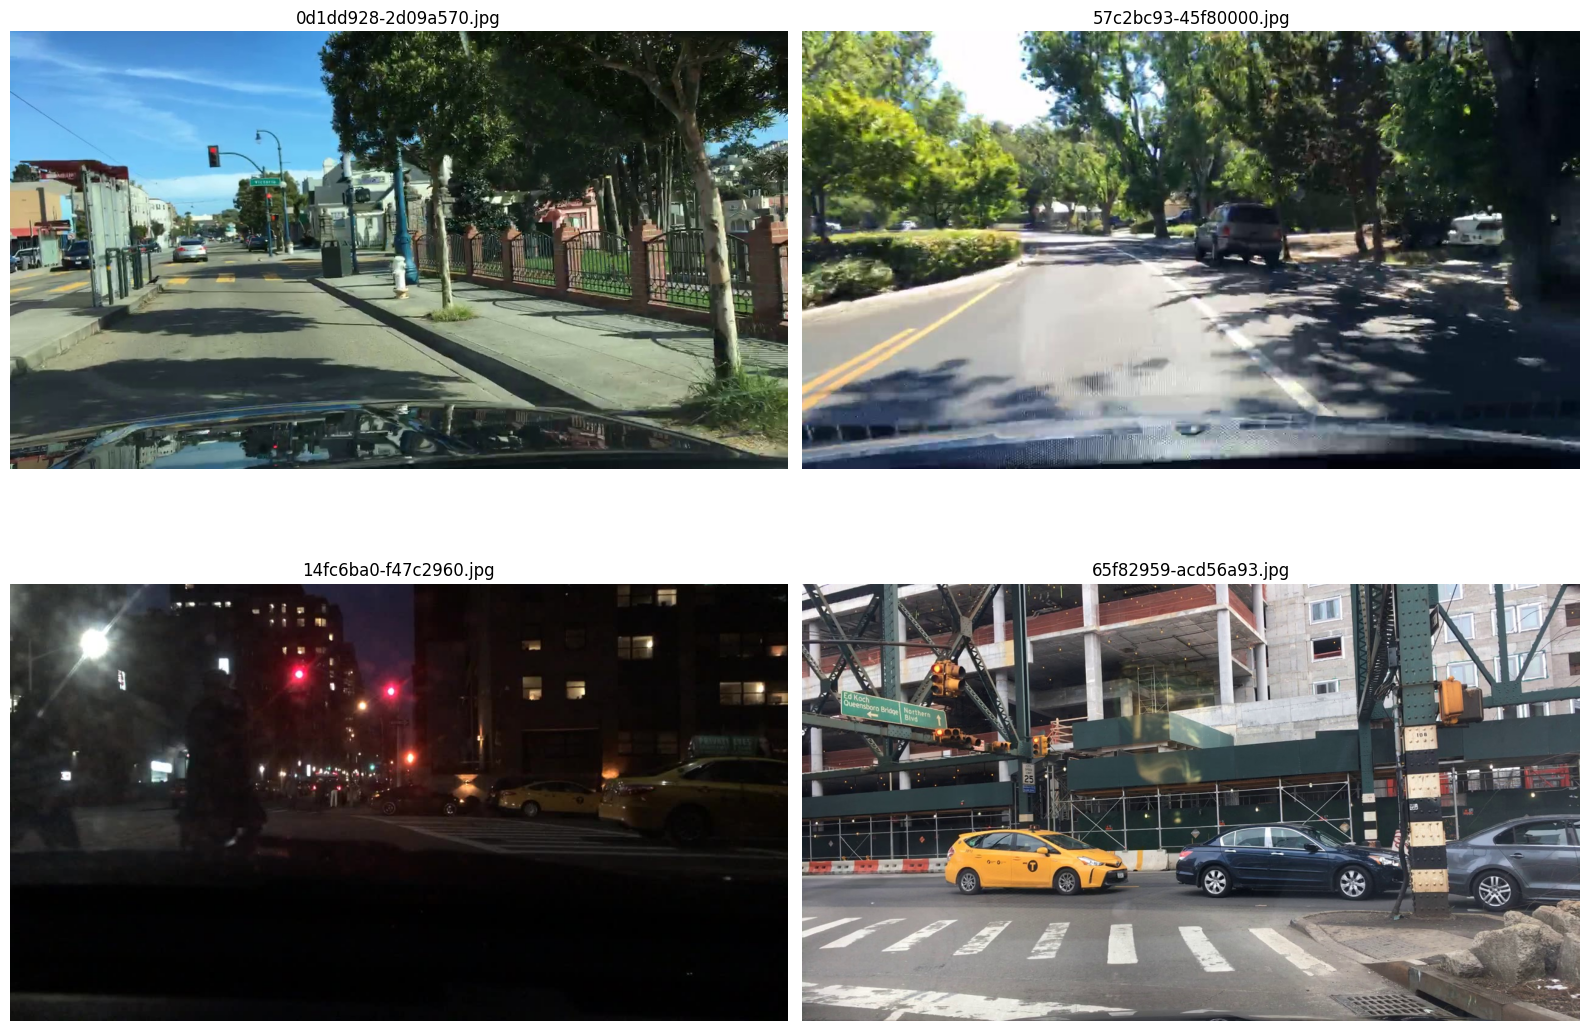

In [ ]:
# ================================
# TRỰC QUAN HÓA DỮ LIỆU SEGMENTATION
# ================================

import random
import numpy as np
import matplotlib.patches as patches

# 1. Phân bố số lượng mask theo class
def count_seg_class_distribution(label_dir):
    counter = Counter()

    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            path = os.path.join(label_dir, label_file)

            with open(path, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()

                if len(parts) >= 7:
                    try:
                        cls_id = int(float(parts[0]))
                        counter[cls_id] += 1
                    except:
                        pass

    return counter

seg_train_counter = count_seg_class_distribution(seg_train_label_dir)

seg_labels = [seg_class_names[i] for i in sorted(seg_train_counter.keys())]
seg_counts = [seg_train_counter[i] for i in sorted(seg_train_counter.keys())]

plt.figure(figsize=(14, 6))
plt.bar(seg_labels, seg_counts)
plt.title('Phân bố số lượng mask theo lớp - BDD100K Train')
plt.xlabel('Lớp')
plt.ylabel('Số lượng mask')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Thống kê số mask trên mỗi ảnh
def masks_per_image(label_dir):
    records = []

    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            path = os.path.join(label_dir, label_file)

            with open(path, 'r') as f:
                lines = f.readlines()

            records.append({
                'label_file': label_file,
                'num_masks': len(lines)
            })

    return pd.DataFrame(records)

df_masks = masks_per_image(seg_train_label_dir)

print("===== THỐNG KÊ SỐ MASK TRÊN MỖI ẢNH =====")
print(df_masks['num_masks'].describe())

plt.figure(figsize=(8, 5))
plt.hist(df_masks['num_masks'], bins=30)
plt.title('Phân bố số lượng mask trên mỗi ảnh')
plt.xlabel('Số mask trong một ảnh')
plt.ylabel('Số lượng ảnh')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 3. Hiển thị ảnh mẫu kèm polygon segmentation
def show_segmentation_samples(img_dir, label_dir, class_names, n=4):
    images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_images = random.sample(images, min(n, len(images)))

    plt.figure(figsize=(16, 12))

    for idx, img_name in enumerate(sample_images):
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + '.txt')

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        ax = plt.subplot(2, 2, idx + 1)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(img_name)

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()

                if len(parts) >= 7:
                    cls_id = int(float(parts[0]))
                    coords = list(map(float, parts[1:]))

                    points = []
                    for i in range(0, len(coords), 2):
                        x = coords[i] * w
                        y = coords[i + 1] * h
                        points.append([x, y])

                    polygon = patches.Polygon(
                        points,
                        closed=True,
                        fill=True,
                        alpha=0.3,
                        edgecolor='red',
                        linewidth=2
                    )
                    ax.add_patch(polygon)

                    x_text, y_text = points[0]
                    ax.text(
                        x_text, y_text,
                        class_names.get(cls_id, str(cls_id)),
                        color='yellow',
                        fontsize=8,
                        bbox=dict(facecolor='black', alpha=0.5)
                    )

    plt.tight_layout()
    plt.show()

show_segmentation_samples(seg_train_img_dir, seg_train_label_dir, seg_class_names, n=4)

#II, Khảo sát mô hình

In [ ]:
import os

# Cấu hình đường dẫn
img_dir = '/content/dataset/images/val'
label_dir = '/content/dataset/labels/val'

# Lấy danh sách file và sắp xếp để khớp tên
images = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
labels = sorted([f for f in os.listdir(label_dir) if f.endswith('.txt')])

# Lấy 5 file đầu tiên
sample_images = images[:5]
sample_labels = labels[:5]

print("--- 5 Ảnh đầu tiên ---")
for i, img in enumerate(sample_images):
    print(f"{i+1}. {os.path.join(img_dir, img)}")

print("\n--- 5 Nhãn đầu tiên ---")
for i, lbl in enumerate(sample_labels):
    print(f"{i+1}. {os.path.join(label_dir, lbl)}")

--- 5 Ảnh đầu tiên ---
1. /content/dataset/images/val/7d06fefd-f7be05a6.jpg
2. /content/dataset/images/val/7d128593-0ccfea4c.jpg
3. /content/dataset/images/val/7d15b18b-1e0d6e3f.jpg
4. /content/dataset/images/val/7d209219-ccdc1a09.jpg
5. /content/dataset/images/val/7d22891c-224788c0.jpg

--- 5 Nhãn đầu tiên ---
1. /content/dataset/labels/val/7d06fefd-f7be05a6_train_id.txt
2. /content/dataset/labels/val/7d128593-0ccfea4c_train_id.txt
3. /content/dataset/labels/val/7d15b18b-1e0d6e3f_train_id.txt
4. /content/dataset/labels/val/7d209219-ccdc1a09_train_id.txt
5. /content/dataset/labels/val/7d22891c-224788c0_train_id.txt


In [ ]:
import os

def final_cleanup(label_path):
    count = 0
    for filename in os.listdir(label_path):
        if "_train_id.txt" in filename:
            # Gọt bỏ phần '_train_id'
            new_name = filename.replace('_train_id', '')

            old_file = os.path.join(label_path, filename)
            new_file = os.path.join(label_path, new_name)

            os.rename(old_file, new_file)
            count += 1
    print(f"✅ Đã chuẩn hóa xong {count} file tại: {label_path}")

# Chạy cho cả train và val trên SSD
final_cleanup('/content/dataset/labels/train')
final_cleanup('/content/dataset/labels/val')

✅ Đã chuẩn hóa xong 7000 file tại: /content/dataset/labels/train
✅ Đã chuẩn hóa xong 1000 file tại: /content/dataset/labels/val


In [ ]:
import os

# Cấu hình đường dẫn thực tế trên SSD của bạn
img_dir = '/content/dataset/images/val'
lbl_dir = '/content/dataset/labels/val'

# Lấy danh sách file, lọc các file ẩn và sắp xếp
images = sorted([f for f in os.listdir(img_dir) if not f.startswith('.')])
labels = sorted([f for f in os.listdir(lbl_dir) if not f.startswith('.')])

print(f"{'STT':<5} | {'Tên tệp Images':<40} | {'Tên tệp Labels':<40}")
print("-" * 90)

# Lấy min của 5 hoặc số lượng file thực tế để tránh lỗi index
for i in range(min(5, len(images), len(labels))):
    print(f"{i+1:<5} | {images[i]:<40} | {labels[i]:<40}")

# Kiểm tra nhanh đuôi file và số lượng
print("-" * 90)
print(f"Tổng cộng: {len(images)} images và {len(labels)} labels.")

STT   | Tên tệp Images                           | Tên tệp Labels                          
------------------------------------------------------------------------------------------
1     | 7d06fefd-f7be05a6.jpg                    | 7d06fefd-f7be05a6.txt                   
2     | 7d128593-0ccfea4c.jpg                    | 7d128593-0ccfea4c.txt                   
3     | 7d15b18b-1e0d6e3f.jpg                    | 7d15b18b-1e0d6e3f.txt                   
4     | 7d209219-ccdc1a09.jpg                    | 7d209219-ccdc1a09.txt                   
5     | 7d22891c-224788c0.jpg                    | 7d22891c-224788c0.txt                   
------------------------------------------------------------------------------------------
Tổng cộng: 1000 images và 1000 labels.


In [ ]:
import os

def filter_invalid_ids(directory, max_allowed_id=18):
    count_fixed = 0
    total_lines_removed = 0

    # Lấy danh sách file .txt
    files = [f for f in os.listdir(directory) if f.endswith('.txt')]

    for filename in files:
        path = os.path.join(directory, filename)
        with open(path, 'r') as f:
            lines = f.readlines()

        # Lọc: Chỉ giữ lại dòng có ID nằm trong khoảng [0, max_allowed_id]
        valid_lines = []
        for line in lines:
            parts = line.split()
            if len(parts) > 0:
                try:
                    cls_id = int(float(parts[0]))
                    if 0 <= cls_id <= max_allowed_id:
                        valid_lines.append(line.strip())
                    else:
                        total_lines_removed += 1
                except ValueError:
                    continue # Bỏ qua dòng lỗi định dạng nếu có

        # Ghi đè lại file (chỉ chứa các dòng hợp lệ)
        with open(path, 'w') as f:
            f.write('\n'.join(valid_lines))
        count_fixed += 1

    print(f"✅ Đã xử lý xong {count_fixed} file tại: {directory}")
    print(f"🗑️ Tổng số dòng (ID 255 hoặc ID lạ) đã bị loại bỏ: {total_lines_removed}")

# 1. Chạy lọc cho thư mục Train
filter_invalid_ids('/content/dataset/labels/train', max_allowed_id=18)

# 2. Chạy lọc cho thư mục Val
filter_invalid_ids('/content/dataset/labels/val', max_allowed_id=18)

# 3. QUAN TRỌNG: Xóa cache cũ để YOLO không đọc lại lỗi
!rm -rf /content/dataset/labels/*.cache
print("🚀 Đã xóa cache. Giờ bạn có thể bấm Train lại rồi đó!")

✅ Đã xử lý xong 7000 file tại: /content/dataset/labels/train
🗑️ Tổng số dòng (ID 255 hoặc ID lạ) đã bị loại bỏ: 0
✅ Đã xử lý xong 1000 file tại: /content/dataset/labels/val
🗑️ Tổng số dòng (ID 255 hoặc ID lạ) đã bị loại bỏ: 0
🚀 Đã xóa cache. Giờ bạn có thể bấm Train lại rồi đó!


In [ ]:
import os

def fix_corrupt_labels(directory):
    count = 0
    for filename in os.listdir(directory):
        if filename.endswith('.txt'):
            path = os.path.join(directory, filename)
            with open(path, 'r') as f:
                content = f.read()

            # Loại bỏ ký tự xuống dòng của Windows và các khoảng trắng thừa
            clean_content = content.replace('\r\n', '\n').strip()

            with open(path, 'w') as f:
                f.write(clean_content)
            count += 1
    print(f"✅ Đã làm sạch {count} file tại: {directory}")

# Chạy cho cả 2 thư mục trên SSD
fix_corrupt_labels('/content/dataset/labels/train')
fix_corrupt_labels('/content/dataset/labels/val')

✅ Đã làm sạch 7000 file tại: /content/dataset/labels/train
✅ Đã làm sạch 1000 file tại: /content/dataset/labels/val


In [ ]:
from ultralytics import YOLO
import os

# Cấu hình
data_yaml = '/content/bdd100k_local.yaml'
survey_path = '/content/drive/MyDrive/TGMT/Segmentation/survey_5_epochs'
models_to_test = ['yolov8n-seg.pt', 'yolov8s-seg.pt', 'yolov8m-seg.pt']
results = {}

for m_name in models_to_test:
    print(f"\n🔍 Đang chạy thử nghiệm nhanh 5 epoch cho: {m_name}...")
    model = YOLO(m_name)
    results_fit = model.train(
        data=data_yaml,
        epochs=1,
        batch=32, # Giảm batch một chút để an toàn cho cả bản m
        imgsz=640,
        device=0,
        project=survey_path,
        name=m_name.replace('.pt', ''),
        exist_ok=True,
        plots=True,
        cache = False
    )
    # Lưu lại mAP50-95 (mask) cuối cùng của epoch 5
    results[m_name] = results_fit.results_dict['metrics/mAP50-95(M)']

# Tìm mô hình tốt nhất
best_model_name = max(results, key=results.get)
print(f"\n Mô hình chiến thắng: {best_model_name} với mAP: {results[best_model_name]}")


🔍 Đang chạy thử nghiệm nhanh 5 epoch cho: yolov8n-seg.pt...
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cpu 


ValueError: Invalid CUDA 'device=0' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): False
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: 0
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.


In [ ]:
from ultralytics import YOLO

# Danh sách các bản cần survey tiếp theo
models_to_test = ['yolov8m-seg.pt']

for m_name in models_to_test:
    print(f"🚀 Đang bắt đầu Survey cho: {m_name}")
    model = YOLO(m_name)

    # Cấu hình Batch size linh hoạt để tránh OOM
    current_batch = 32 if 's-seg' in m_name else 16

    model.train(
        data='/content/bdd100k_local.yaml',
        epochs=1,           # Chỉ chạy 1 epoch để đo tốc độ/khớp dữ liệu
        imgsz=640,
        batch=current_batch,
        project='/content/drive/MyDrive/TGMT/Segmentation/survey_5_epoch',
        name=m_name.replace('.pt', ''),
        device=0
    )

🚀 Đang bắt đầu Survey cho: yolov8m-seg.pt
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bdd100k_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m-seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

#III, So sánh các chỉ số sau khảo sát

         --- BẢNG SO SÁNH CHỈ SỐ SEGMENTATION (MASK) ---


,Model,Precision,Recall,mAP50,mAP50-95,F1-Score
0,YOLOv8n-seg,0.553060,0.117830,0.108730,0.055770,0.194270
1,YOLOv8s-seg,0.406300,0.220550,0.202380,0.106990,0.285904
2,YOLOv8m-seg,0.394010,0.249500,0.248660,0.130680,0.305529


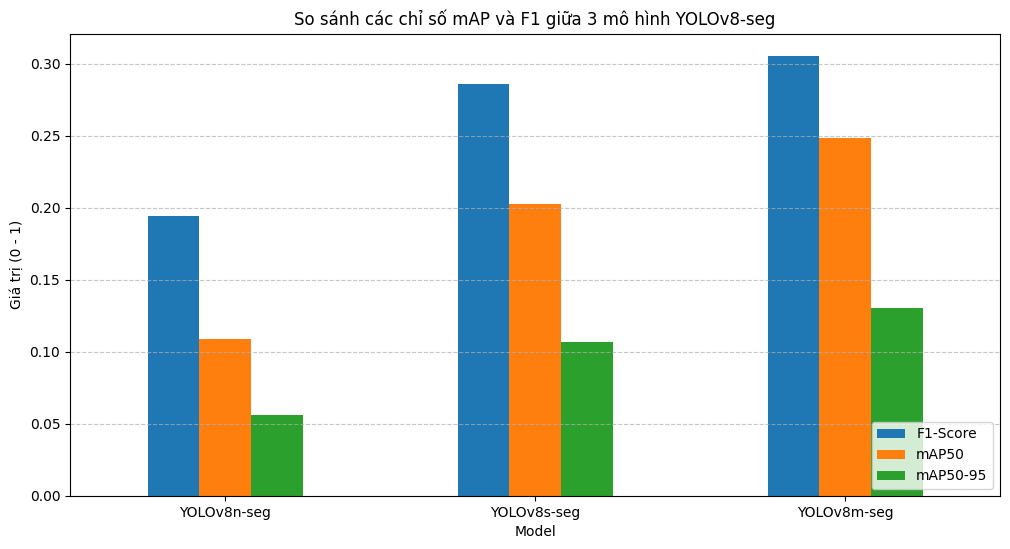

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Cấu hình đường dẫn đến 3 thư mục kết quả trên Drive của bạn
base_path = '/content/drive/MyDrive/TGMT/Segmentation/survey_5_epochs'
models = {
    'YOLOv8n-seg': os.path.join(base_path, 'yolov8n-seg'),
    'YOLOv8s-seg': os.path.join(base_path, 'yolov8s-seg'),
    'YOLOv8m-seg': os.path.join(base_path, 'yolov8m-seg')
}

all_stats = []

# 2. Đọc dữ liệu từ file results.csv của từng mô hình
for name, path in models.items():
    csv_file = os.path.join(path, 'results.csv')
    if os.path.exists(csv_file):
        df = pd.read_csv(csv_file)
        # Loại bỏ khoảng trắng thừa trong tên cột nếu có
        df.columns = [c.strip() for c in df.columns]

        # Lấy dòng cuối cùng (Epoch 5)
        last_epoch = df.iloc[-1]

        # Trích xuất các chỉ số (YOLOv8 lưu mAP mask riêng)
        stats = {
            'Model': name,
            'Precision': last_epoch['metrics/precision(M)'],
            'Recall': last_epoch['metrics/recall(M)'],
            'mAP50': last_epoch['metrics/mAP50(M)'],
            'mAP50-95': last_epoch['metrics/mAP50-95(M)'],
        }

        # Tính toán F1-Score (F1 = 2 * (P * R) / (P + R))
        p = stats['Precision']
        r = stats['Recall']
        stats['F1-Score'] = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        all_stats.append(stats)
    else:
        print(f"⚠️ Cảnh báo: Không tìm thấy file tại {name}")

# 3. Tạo DataFrame tổng hợp
report_df = pd.DataFrame(all_stats)

# 4. Hiển thị bảng so sánh
print("         --- BẢNG SO SÁNH CHỈ SỐ SEGMENTATION (MASK) ---")
display(report_df.style.highlight_max(axis=0, color='gray'))

# 5. Vẽ biểu đồ cột để trực quan hóa
metrics_to_plot = ['F1-Score', 'mAP50', 'mAP50-95']
report_df.set_index('Model')[metrics_to_plot].plot(kind='bar', figsize=(12, 6))
plt.title('So sánh các chỉ số mAP và F1 giữa 3 mô hình YOLOv8-seg')
plt.ylabel('Giá trị (0 - 1)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

📂 Đang kiểm tra kết quả trong Google Drive...

✅ Đã tìm thấy Ma trận nhầm lẫn của: yolov8n-seg


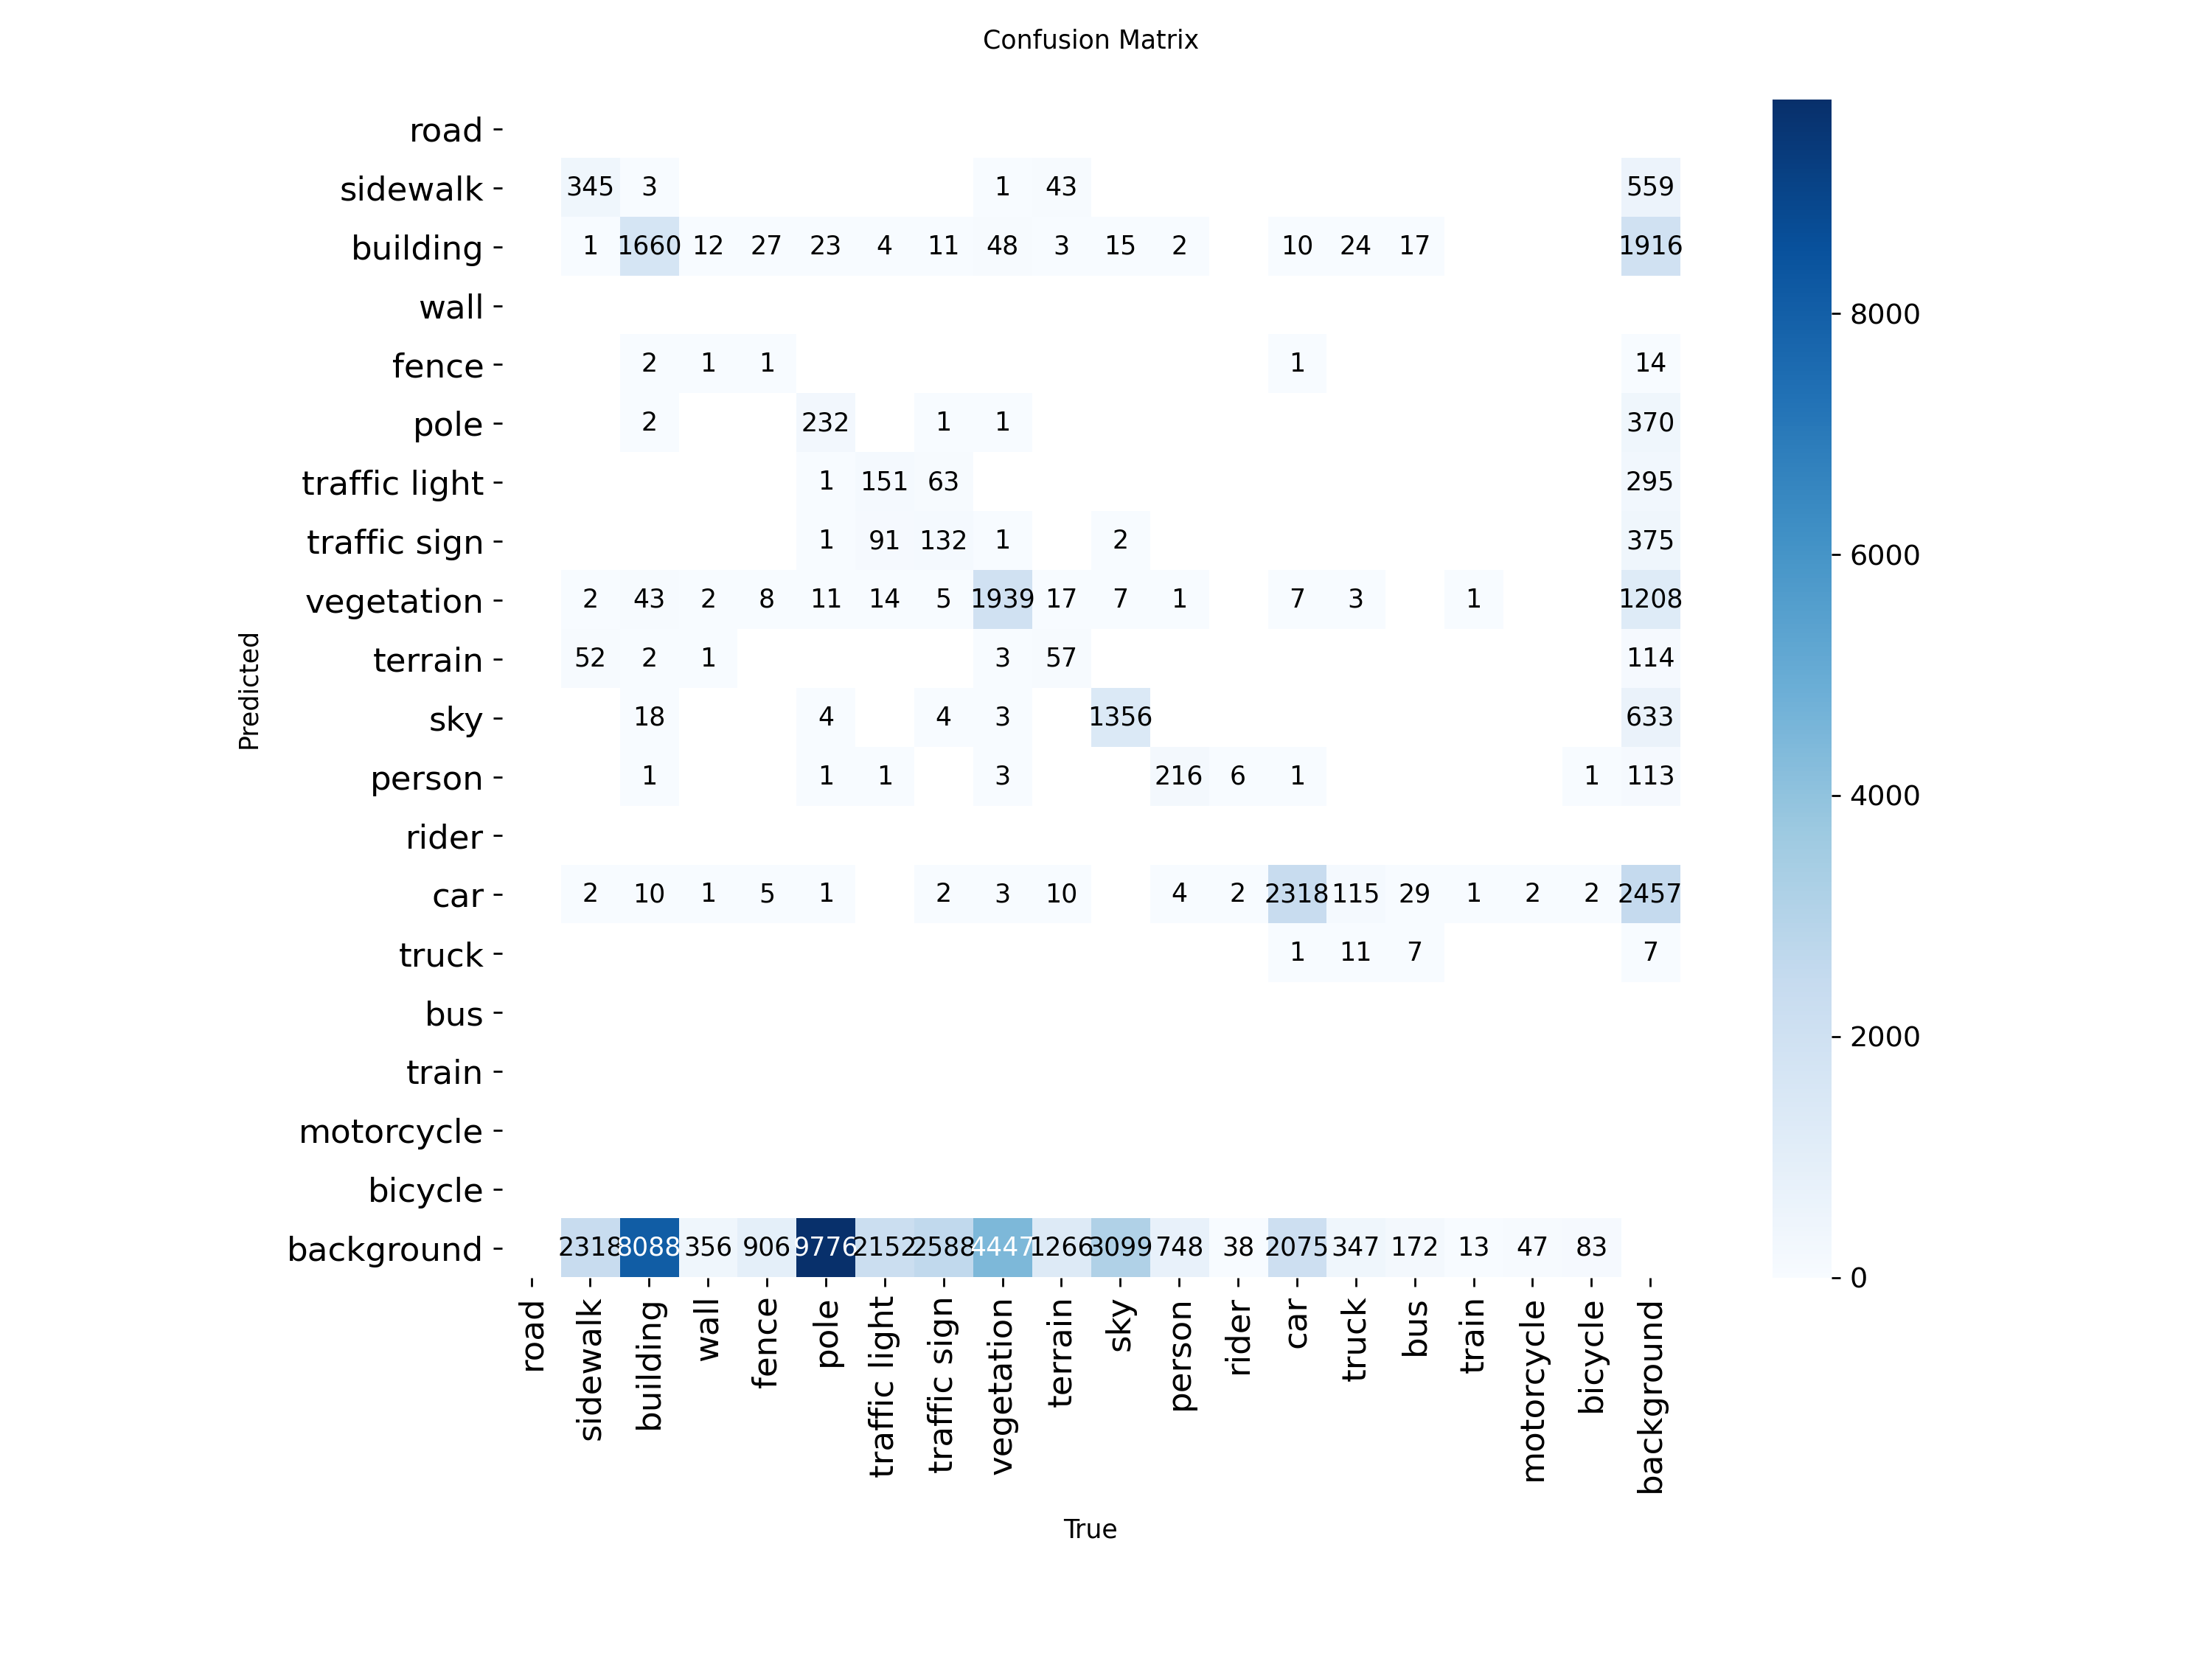


✅ Đã tìm thấy Ma trận nhầm lẫn của: yolov8s-seg


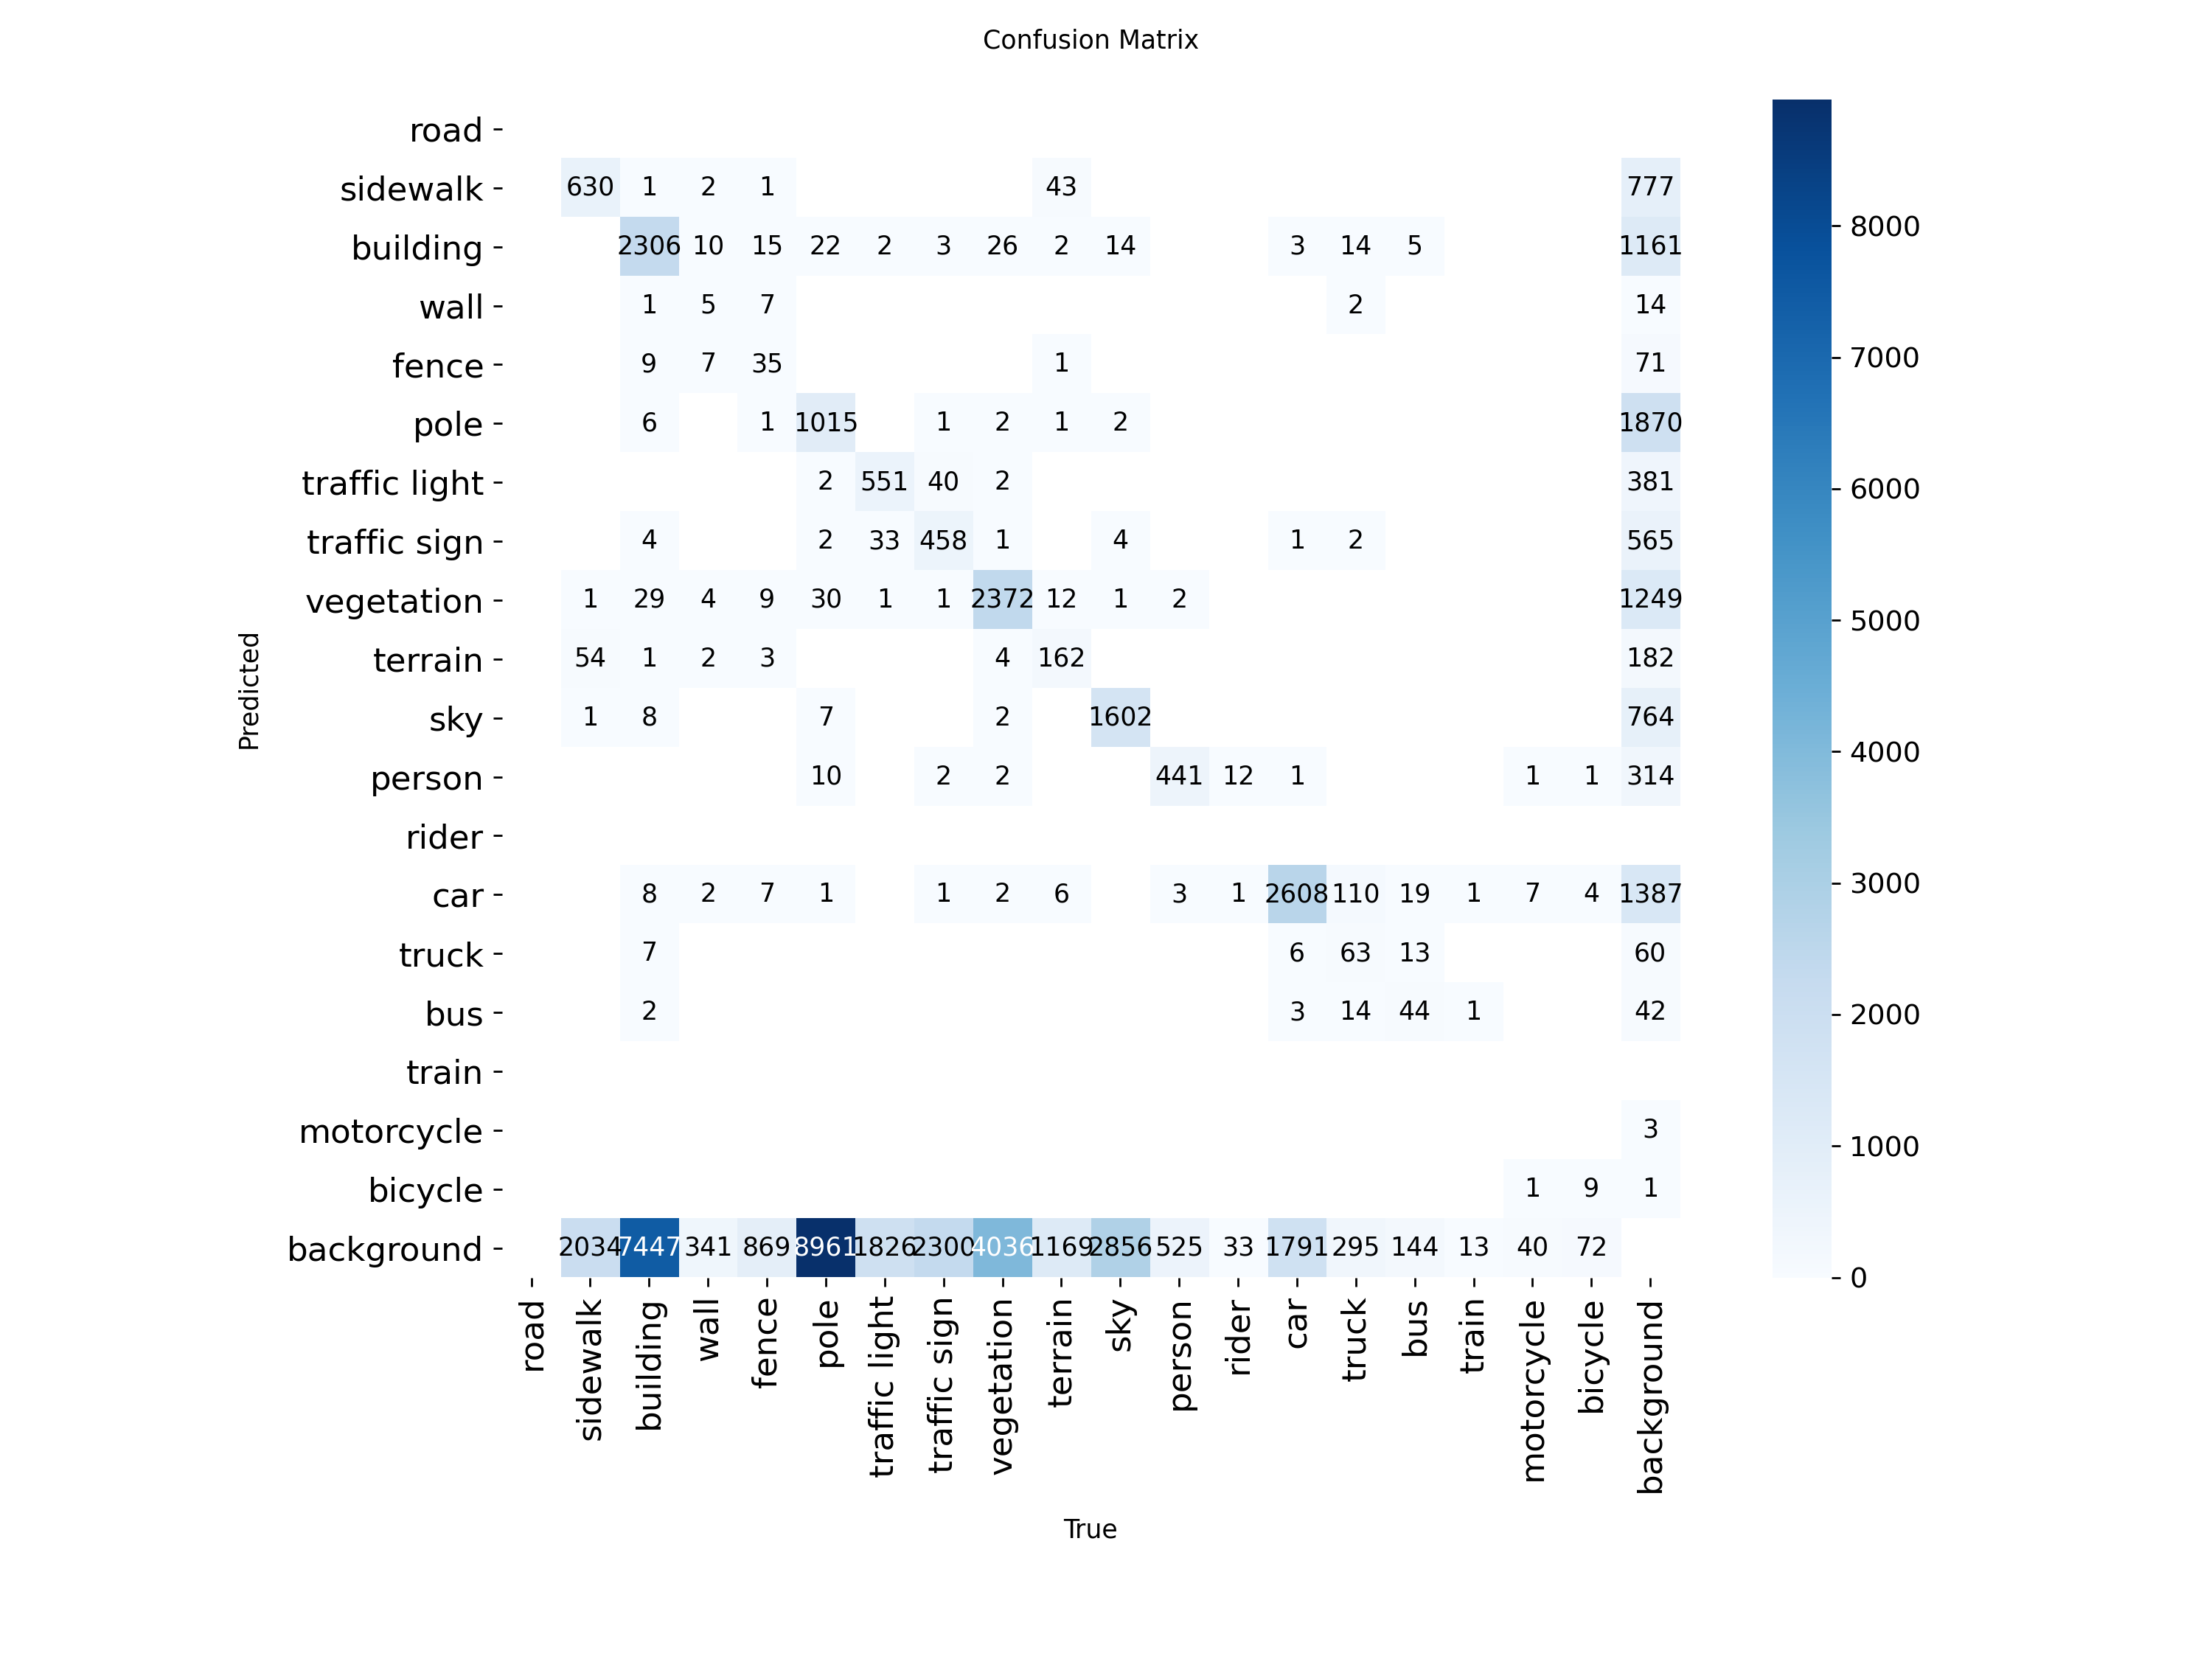


✅ Đã tìm thấy Ma trận nhầm lẫn của: yolov8m-seg


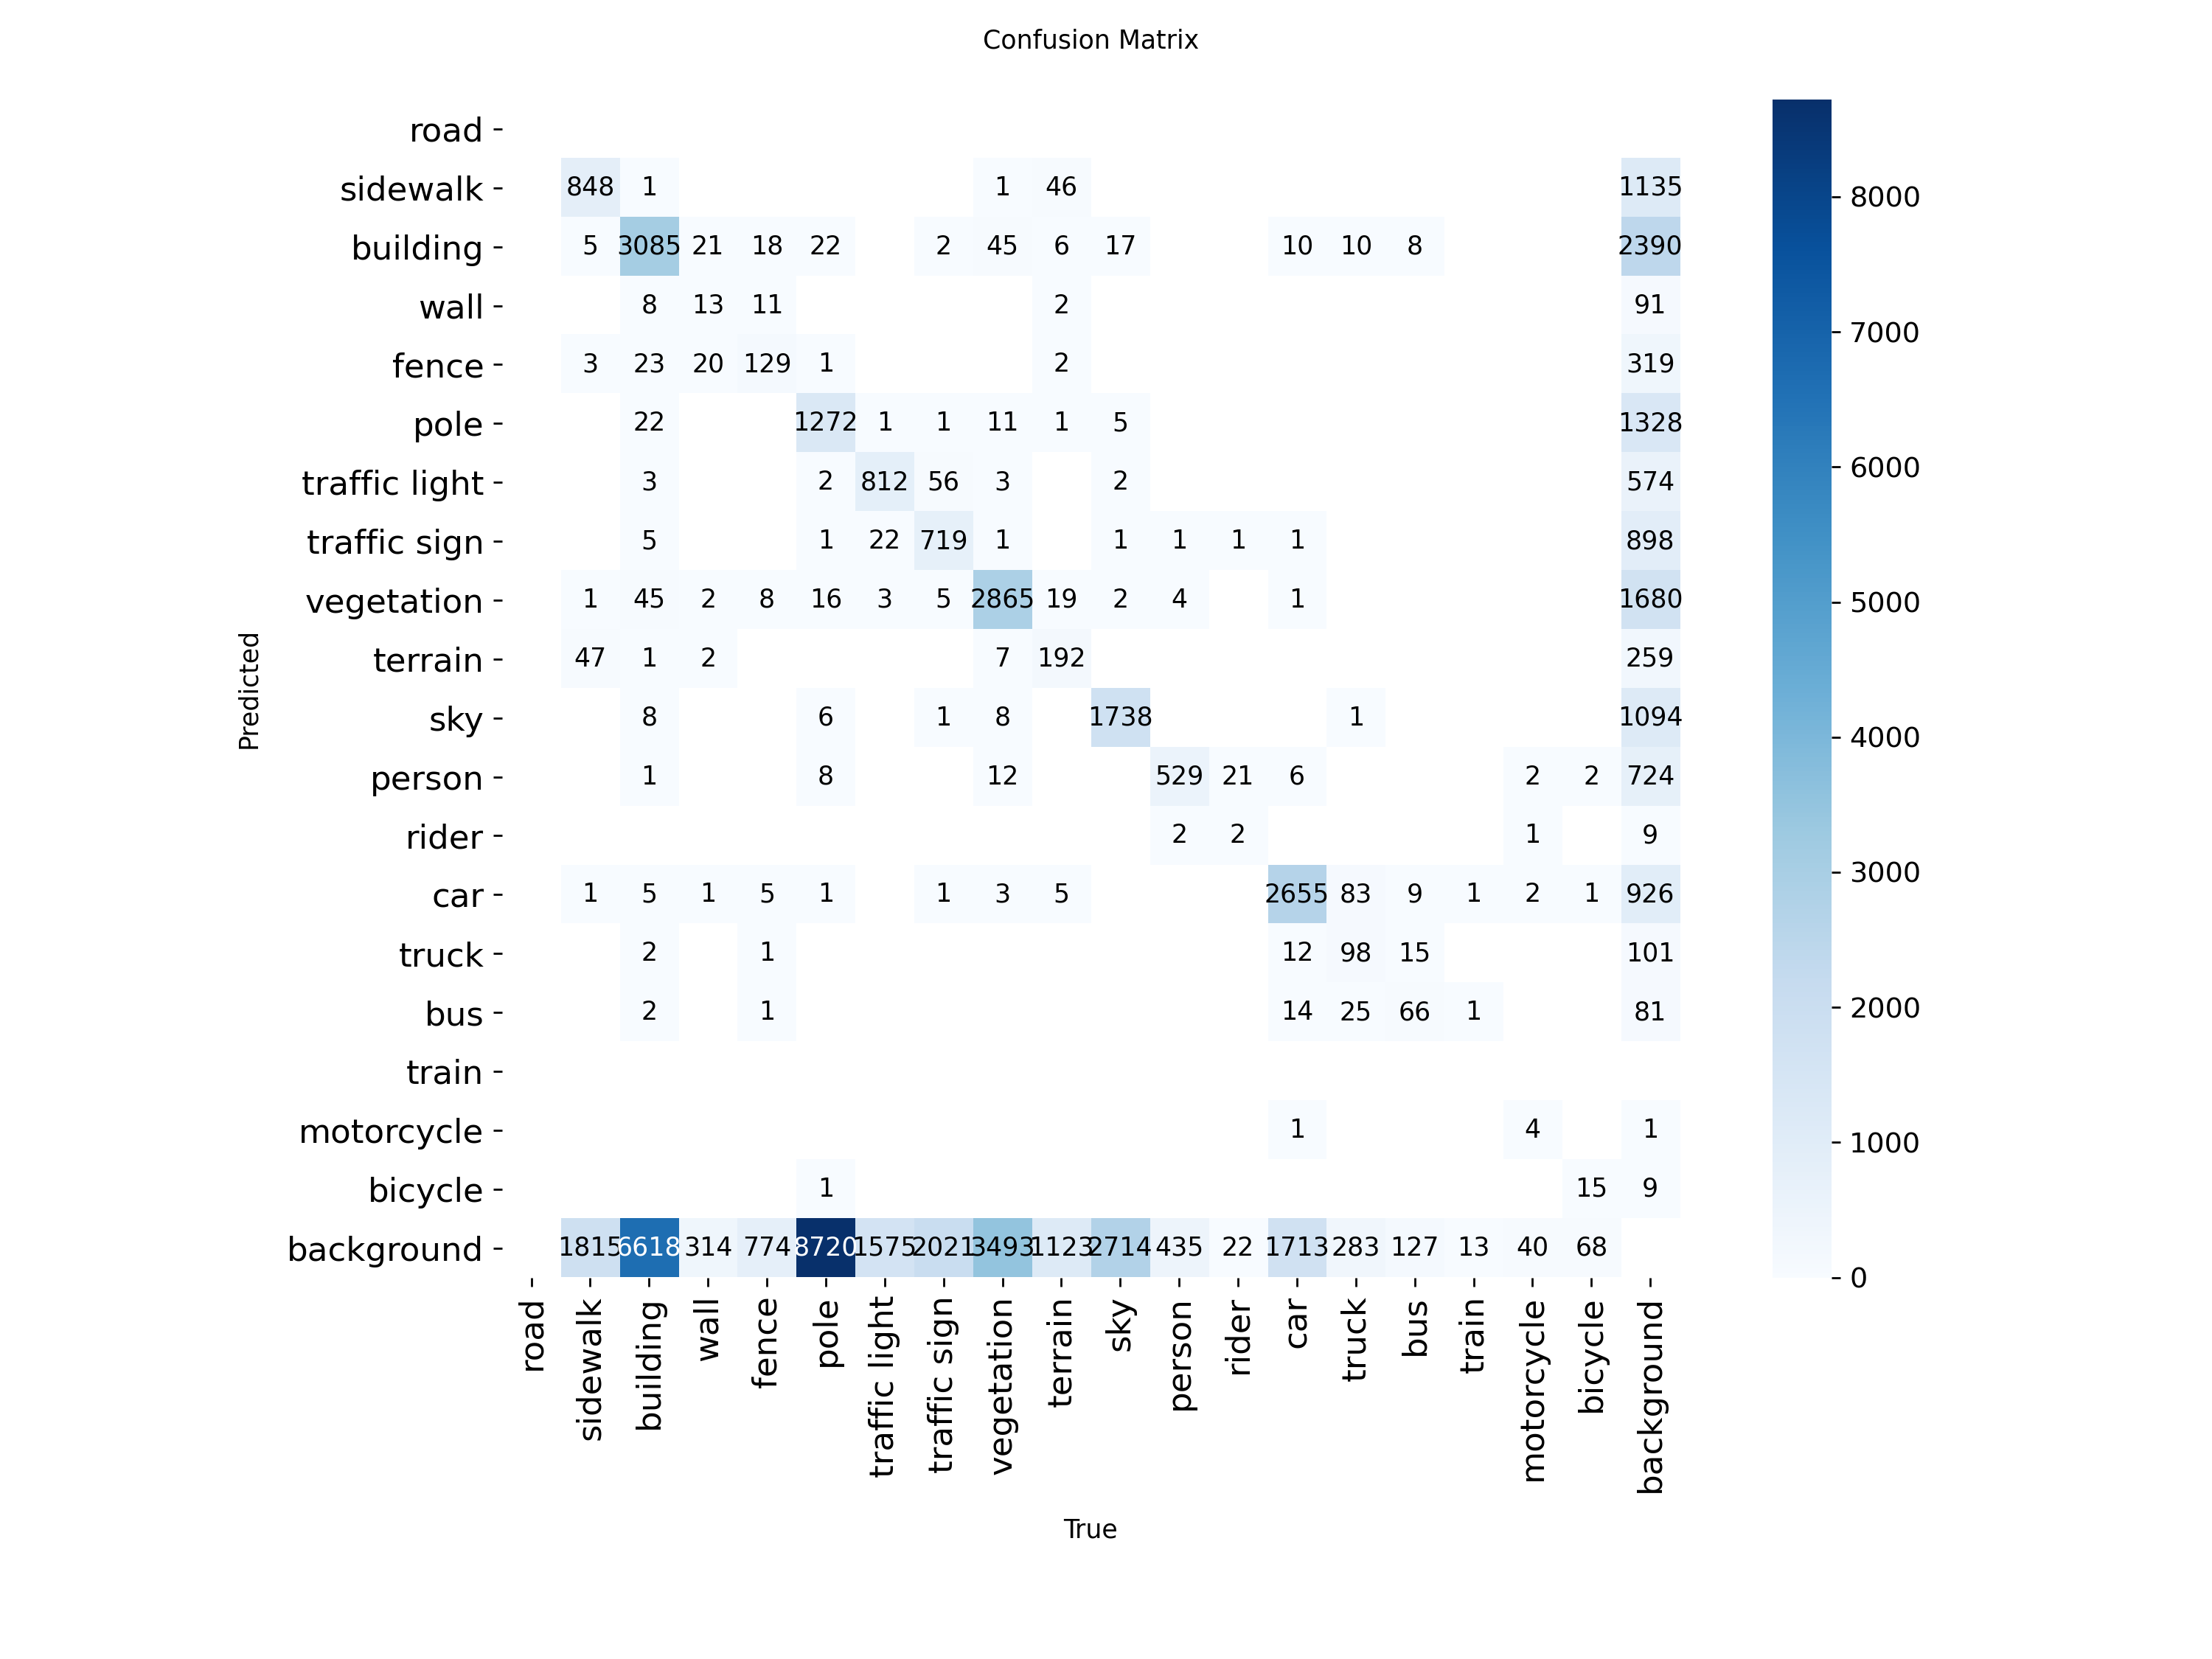

In [ ]:
import os
from IPython.display import Image, display

# 1. Đường dẫn gốc tới thư mục survey trên Drive của bạn
project_path = '/content/drive/MyDrive/TGMT/Segmentation/survey_5_epochs'

# 2. Tên 3 folder mô hình bạn đã lưu (v8n, v8s, v8m)
survey_models = ['yolov8n-seg', 'yolov8s-seg', 'yolov8m-seg']

print("📂 Đang kiểm tra kết quả trong Google Drive...")

for m_name in survey_models:
    # Thường khi train xong, YOLO lưu ma trận ngay trong folder chạy
    # Đường dẫn mặc định: project_path/m_name/confusion_matrix.png
    cm_path = os.path.join(project_path, m_name, 'confusion_matrix.png')

    if os.path.exists(cm_path):
        print(f"\n✅ Đã tìm thấy Ma trận nhầm lẫn của: {m_name}")
        display(Image(filename=cm_path, width=600))
    else:
        print(f"\n🔍 Không thấy file sẵn có cho {m_name}, đang tiến hành tạo mới từ trọng số...")
        # Nếu chưa có file ảnh sẵn, ta dùng file weights để chạy val lấy ma trận
        weights_path = os.path.join(project_path, m_name, 'weights/last.pt')

        if os.path.exists(weights_path):
            from ultralytics import YOLO
            model = YOLO(weights_path)
            # Chú ý: Đảm bảo file .yaml và folder ảnh val đang tồn tại trên Colab
            results = model.val(data='/content/bdd100k_local.yaml', split='val', plots=True, name=f"fix_{m_name}")
            new_cm = os.path.join(results.save_dir, 'confusion_matrix.png')
            display(Image(filename=new_cm, width=600))
        else:
            print(f"❌ Không tìm thấy cả trọng số tại: {weights_path}")

Dựa trên VRam và các chỉ số, Yolov8s là lựa chọn tối ưu nhất cho đến thời điểm hiện tại

#IV, Huấn luyện nâng cao với 3 chiến lược tinh chỉnh mô hình

In [ ]:
import os
import random
import shutil
from tqdm import tqdm

def create_subset(src_img_dir, src_lbl_dir, dest_root, k=5000):
    dest_img_dir = os.path.join(dest_root, 'images/train')
    dest_lbl_dir = os.path.join(dest_root, 'labels/train')
    os.makedirs(dest_img_dir, exist_ok=True)
    os.makedirs(dest_lbl_dir, exist_ok=True)

    # Lấy danh sách tất cả ảnh trong tập train gốc
    all_images = [f for f in os.listdir(src_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Chọn ngẫu nhiên 5000 ảnh
    sampled_images = random.sample(all_images, k)

    print(f"🚀 Đang sao chép {k} ảnh và nhãn sang thư mục mới...")
    for img_name in tqdm(sampled_images):
        # Sao chép ảnh
        shutil.copy(os.path.join(src_img_dir, img_name), os.path.join(dest_img_dir, img_name))

        # Sao chép nhãn tương ứng (đổi đuôi sang .txt)
        lbl_name = os.path.splitext(img_name)[0] + '.txt'
        src_lbl_path = os.path.join(src_lbl_dir, lbl_name)
        if os.path.exists(src_lbl_path):
            shutil.copy(src_lbl_path, os.path.join(dest_lbl_dir, lbl_name))

# Chạy lệnh trích xuất
create_subset(
    src_img_dir='/content/dataset/images/train',
    src_lbl_dir='/content/dataset/labels/train',
    dest_root='/content/dataset_5k'
)

# Link tập Val gốc sang thư mục mới để dùng chung
!ln -s /content/dataset/images/val /content/dataset_5k/images/val
!ln -s /content/dataset/labels/val /content/dataset_5k/labels/val

🚀 Đang sao chép 5000 ảnh và nhãn sang thư mục mới...


100%|██████████| 5000/5000 [00:14<00:00, 346.32it/s]


In [ ]:
yaml_content = """
path: /content/dataset_5k
train: images/train
val: images/val

nc: 19
names: ['road', 'sidewalk', 'building', 'wall', 'fence', 'pole', 'traffic light', 'traffic sign', 'vegetation', 'terrain', 'sky', 'person', 'rider', 'car', 'truck', 'bus', 'train', 'motorcycle', 'bicycle']
"""

with open('/content/bdd100k_5k.yaml', 'w') as f:
    f.write(yaml_content)

In [ ]:
from ultralytics import YOLO

# Khởi tạo mô hình Small
model = YOLO('yolov8s-seg.pt')

# Bắt đầu huấn luyện 100 Epoch
results = model.train(
    data='/content/bdd100k_5k.yaml',
    epochs=100,
    imgsz=640,
    batch=32,
    workers=8,
    device=0,

    # --- Data Augmentation Cấu hình mạnh ---
    mosaic=1.0,      # Tỉ lệ ảnh sử dụng Mosaic (ghép 4 ảnh thành 1)
    mixup=0.5,       # Tỉ lệ sử dụng Mixup (chồng 2 ảnh lên nhau)
    fliplr=0.5,      # Lật ảnh trái-phải (tỉ lệ 50%)
    flipud=0.0,      # Lật ảnh trên-dưới (thường không dùng cho giao thông)
    degrees=10.0,    # Xoay nhẹ ảnh trong khoảng +/- 10 độ

    # --- Quản lý hệ thống ---
    project='/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K',
    name='v8s_100ep_augmented',
    save=True,
    save_period=10,
    cache=True,      # Tăng tốc nạp ảnh từ RAM
    patience=20,     # Dừng sớm nếu không cải thiện
    exist_ok=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bdd100k_5k.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8s_100ep_augmented, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, pe

function ClickConnect(){
  console.log("Đang giữ kết nối...");
  document.querySelector("colab-connect-button").click()
}
setInterval(ClickConnect, 60000)

In [ ]:
from ultralytics import YOLO

# 1. Đường dẫn đến file trọng số cuối cùng được lưu trên Drive
# YOLOv8 luôn lưu file 'last.pt' là trạng thái mới nhất (trong trường hợp này là epoch 40)
checkpoint_path = '/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented/weights/last.pt'

# 2. Load model từ checkpoint đó
model = YOLO(checkpoint_path)

# 3. Kích hoạt lệnh Resume
# Bạn không cần điền lại các tham số batch, imgsz... vì nó đã được lưu trong file .pt
model.train(resume=True)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bdd100k_5k.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8s_100ep_augmented, nbs=64, nms=False, o

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented/weights/last.pt')

# Chạy nốt
model.train(
    resume=True,
    batch=64,      # Vì bạn đã có GPU xịn hơn
    workers=12,    # Tăng luồng nạp dữ liệu
    amp=True       # Đảm bảo bật chế độ tăng tốc phần cứng
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bdd100k_5k.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8s_100ep_augmented, nbs=64,

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d3d4dfbee40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.0360

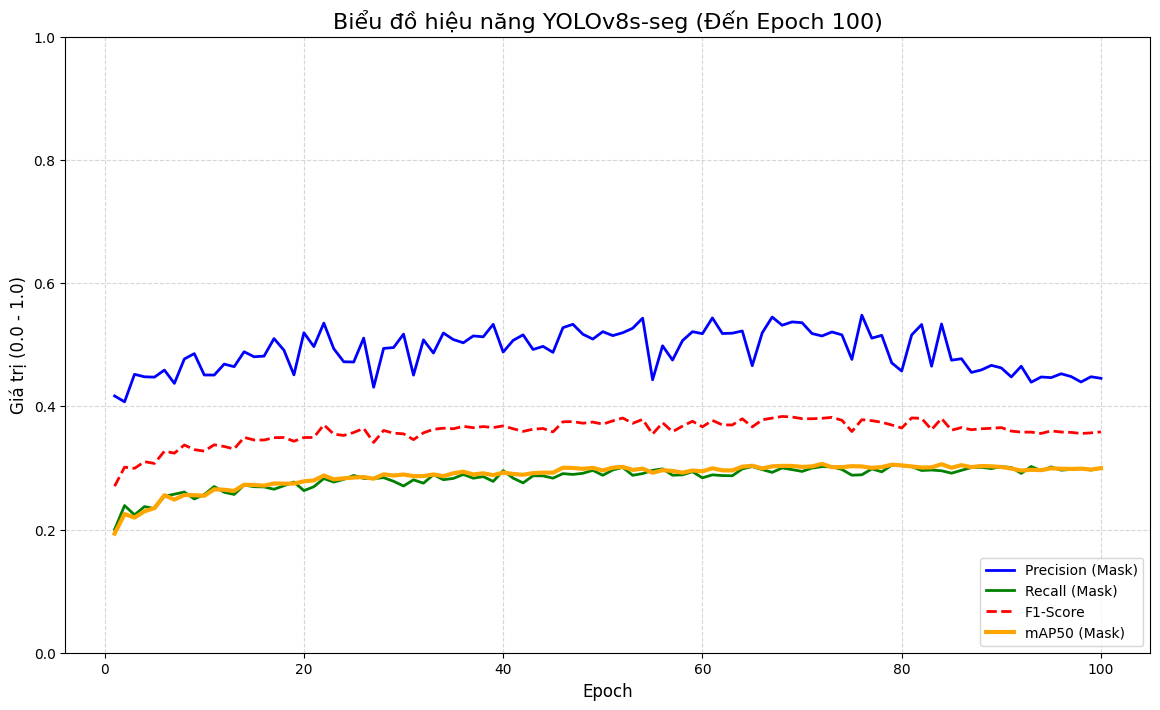

✅ Đã vẽ xong biểu đồ cho 100 epoch!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Đường dẫn tới file kết quả trên Drive của Đức Anh
csv_path = '/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented/results.csv'

if os.path.exists(csv_path):
    # 2. Đọc dữ liệu
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns] # Xóa khoảng trắng thừa trong tên cột

    # 3. Tính toán F1-Score thủ công (F1 = 2 * P * R / (P + R))
    # Lưu ý: YOLOv8-seg lưu chỉ số Mask (M) riêng
    p = df['metrics/precision(M)']
    r = df['metrics/recall(M)']
    df['F1-Score'] = 2 * (p * r) / (p + r)

    # 4. Vẽ biểu đồ
    plt.figure(figsize=(14, 8))

    epochs = df['epoch']
    plt.plot(epochs, df['metrics/precision(M)'], label='Precision (Mask)', color='blue', linewidth=2)
    plt.plot(epochs, df['metrics/recall(M)'], label='Recall (Mask)', color='green', linewidth=2)
    plt.plot(epochs, df['F1-Score'], label='F1-Score', color='red', linestyle='--', linewidth=2)
    plt.plot(epochs, df['metrics/mAP50(M)'], label='mAP50 (Mask)', color='orange', linewidth=3)

    # 5. Trang trí biểu đồ
    plt.title(f'Biểu đồ hiệu năng YOLOv8s-seg (Đến Epoch {epochs.max()})', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Giá trị (0.0 - 1.0)', fontsize=12)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.ylim(0, 1.0) # Giới hạn trục Y từ 0 đến 1

    # Lưu ảnh biểu đồ để đưa vào báo cáo
    plt.savefig('/content/training_progress_70ep.png', dpi=300)
    plt.show()

    print(f"✅ Đã vẽ xong biểu đồ cho {epochs.max()} epoch!")
else:
    print("⚠️ Không tìm thấy file results.csv. Đức Anh kiểm tra lại đường dẫn trên Drive nhé!")

In [ ]:
# 1. Đường dẫn các mô hình
model_survey_path = '/content/drive/MyDrive/TGMT/Segmentation/survey_5_epochs/yolov8s-seg/weights/best.pt'  # Mô hình khảo sát (gốc)
model_tuned_path = '/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented/weights/best.pt' # Mô hình của bạn
data_yaml = '/content/drive/MyDrive/TGMT/Segmentation/bdd100k.yaml'

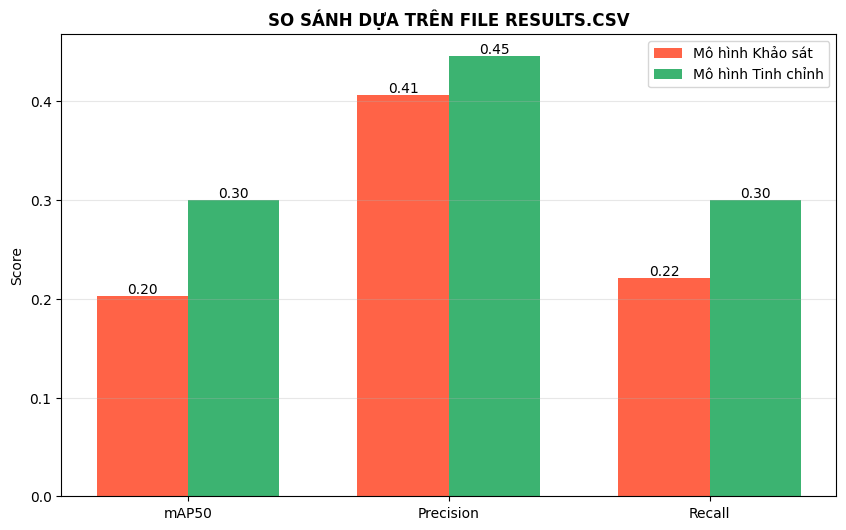

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Đường dẫn tới file results.csv của 2 mô hình
path_survey = '/content/drive/MyDrive/TGMT/Segmentation/survey_5_epochs/yolov8s-seg/results.csv'
path_tuned = '/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented/results.csv'

# 2. Đọc dữ liệu
df_survey = pd.read_csv(path_survey)
df_tuned = pd.read_csv(path_tuned)

# Xóa khoảng trắng thừa trong tên cột
df_survey.columns = [c.strip() for c in df_survey.columns]
df_tuned.columns = [c.strip() for c in df_tuned.columns]

# 3. Lấy dòng cuối cùng (kết quả sau khi kết thúc quá trình train/val)
# Cột thường là: 'metrics/mAP50(M)', 'metrics/precision(M)', 'metrics/recall(M)'
m_survey = [
    df_survey['metrics/mAP50(M)'].iloc[-1],
    df_survey['metrics/precision(M)'].iloc[-1],
    df_survey['metrics/recall(M)'].iloc[-1]
]

m_tuned = [
    df_tuned['metrics/mAP50(M)'].iloc[-1],
    df_tuned['metrics/precision(M)'].iloc[-1],
    df_tuned['metrics/recall(M)'].iloc[-1]
]

# 4. Vẽ biểu đồ plt
labels = ['mAP50', 'Precision', 'Recall']
x = [0, 1, 2]
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], m_survey, width, label='Mô hình Khảo sát', color='tomato')
plt.bar([i + width/2 for i in x], m_tuned, width, label='Mô hình Tinh chỉnh', color='mediumseagreen')

plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('SO SÁNH DỰA TRÊN FILE RESULTS.CSV', fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Ghi số lên đầu cột
for i in range(len(x)):
    plt.text(i - width/2, m_survey[i], f'{m_survey[i]:.2f}', ha='center', va='bottom')
    plt.text(i + width/2, m_tuned[i], f'{m_tuned[i]:.2f}', ha='center', va='bottom')

plt.show()

✅ Đã tìm thấy Ma trận nhầm lẫn tại: /content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented/confusion_matrix.png


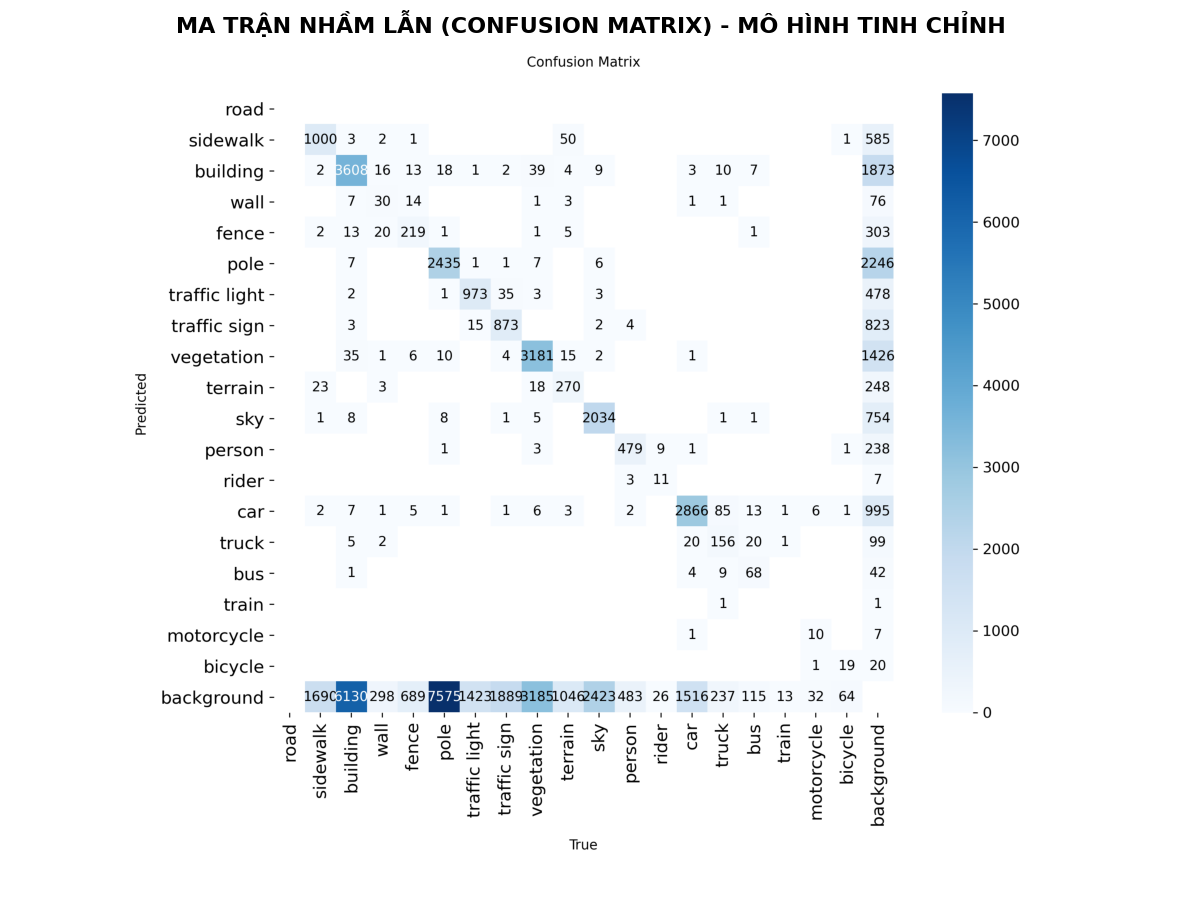

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Đường dẫn tới thư mục chứa kết quả train 100 epoch của bạn trên Drive
# Đức Anh check kỹ lại tên folder 'Final_Train_5K/v8s_100ep_augmented' xem có đúng không nhé
tuned_result_path = '/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented'

# 2. Tên file ảnh ma trận nhầm lẫn mặc định của YOLO
cm_filename = 'confusion_matrix.png'
# Ngoài ra còn có confusion_matrix_normalized.png (dạng tỷ lệ %)

# 3. Tạo đường dẫn đầy đủ
cm_path = os.path.join(tuned_result_path, cm_filename)

# 4. Kiểm tra và hiển thị ảnh bằng plt
if os.path.exists(cm_path):
    print(f"✅ Đã tìm thấy Ma trận nhầm lẫn tại: {cm_path}")

    # Đọc và hiển thị ảnh
    img = mpimg.imread(cm_path)

    # Thiết lập kích thước hiển thị lớn để dễ nhìn
    plt.figure(figsize=(15, 12))
    plt.imshow(img)
    plt.axis('off') # Ẩn trục tọa độ
    plt.title('MA TRẬN NHẦM LẪN (CONFUSION MATRIX) - MÔ HÌNH TINH CHỈNH', fontweight='bold', fontsize=16)
    plt.show()
else:
    print(f"❌ Không tìm thấy file {cm_filename} trong thư mục: {tuned_result_path}")
    print("💡 Đức Anh hãy kiểm tra lại đường dẫn folder trên Drive của bạn.")

#v, Test định lượng

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. Load model best.pt
model = YOLO('/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented/weights/best.pt')

# 2. Mở file video
video_path = '/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/vdeo.mp4' # Thay bằng file của bạn
cap = cv2.VideoCapture(video_path)

# Lấy thông số video để lưu file đầu ra
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Thay đổi dòng này trong code cũ
save_path = '/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/output_video_final.mp4'
out = cv2.VideoWriter(save_path, cv2.VideoWriter_fourcc(*'MP4V'), fps, (frame_width, frame_height))
print("🚀 Đang xử lý video... Vui lòng đợi.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Chạy dự đoán từng frame
    results = model.predict(frame, conf=0.25, verbose=False)

    for r in results:
        annotated_frame = r.plot() # Vẽ mask/box mặc định

        # --- PHẦN ĐỊNH LƯỢNG VÀ ĐẾM ---
        counts = {}
        if r.masks is not None:
            for i, mask in enumerate(r.masks.data):
                cls = int(r.boxes.cls[i])
                label = r.names[cls]
                counts[label] = counts.get(label, 0) + 1

        # Vẽ bảng thống kê trực tiếp lên Frame video (Góc trái màn hình)
        y_pos = 40
        cv2.putText(annotated_frame, "THONG KE DINH LUONG:", (20, y_pos),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        for label, count in counts.items():
            y_pos += 30
            text = f"- {label}: {count}"
            cv2.putText(annotated_frame, text, (30, y_pos),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # Lưu frame đã xử lý vào file video mới
        out.write(annotated_frame)
import math

# ... (Giữ nguyên phần khởi tạo model và video ở code trước) ...

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    results = model.predict(frame, conf=0.3, imgsz=640, verbose=False)

    for r in results:
        annotated_frame = r.plot(line_width=2)
        centroids = [] # Lưu tọa độ tâm: (x, y, label)

        if r.masks is not None:
            # 1. Lấy tọa độ tâm của từng vật thể từ Box hoặc Mask
            for i, box in enumerate(r.boxes.xywh): # xywh: x_center, y_center, width, height
                x_c, y_c, w, h = box
                label = r.names[int(r.boxes.cls[i])]
                centroids.append((int(x_c), int(y_c), label))

            # 2. Tính khoảng cách giữa các cặp vật thể (ví dụ: Khoảng cách giữa các xe)
            for i in range(len(centroids)):
                for j in range(i + 1, len(centroids)):
                    x1, y1, label1 = centroids[i]
                    x2, y2, label2 = centroids[j]

                    # Chỉ tính khoảng cách nếu là các lớp quan trọng (ví dụ: car với car, hoặc car với person)
                    if label1 in ['car', 'person', 'motorcycle'] and label2 in ['car', 'person', 'motorcycle']:
                        # Công thức tính khoảng cách Euclid
                        dist_pixel = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

                        # Vẽ đường nối giữa 2 tâm
                        if dist_pixel < 200: # Chỉ vẽ nếu chúng ở gần nhau (tránh rối mắt)
                            cv2.line(annotated_frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
                            # Hiển thị khoảng cách (pixel)
                            cv2.putText(annotated_frame, f"{int(dist_pixel)}px",
                                        (int((x1+x2)/2), int((y1+y2)/2)),
                                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

        out.write(annotated_frame)
cap.release()
out.release()
print("✅ Hoàn thành! File video kết quả: output_quantified.mp4")

🚀 Đang xử lý video... Vui lòng đợi.
✅ Hoàn thành! File video kết quả: output_quantified.mp4


In [ ]:
import math
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1. Load model
model = YOLO('/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented/weights/best.pt')

cap = cv2.VideoCapture('/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/distance.mp4')
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(3))
height = int(cap.get(4))
save_dir = '/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

save_path = os.path.join(save_dir, 'Video_Dinh_Luong_Distance.mp4')

out = cv2.VideoWriter(save_path, cv2.VideoWriter_fourcc(*'MP4V'), fps, (width, height))
tracked_ids = {}

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    # Chạy Tracking
    results = model.track(frame, persist=True, conf=0.3, imgsz=640, verbose=False)

    for r in results:
        annotated_frame = r.plot(line_width=2)
        centroids = [] # Lưu: (x, y, label, id)

        if r.boxes.id is not None:
            ids = r.boxes.id.int().cpu().tolist()
            clss = r.boxes.cls.int().cpu().tolist()
            boxes = r.boxes.xywh.cpu().numpy() # Tâm x, tâm y, w, h

            for i, id_obj in enumerate(ids):
                label = r.names[clss[i]]
                x_c, y_c, w, h = boxes[i]

                # Cập nhật tổng số lượng duy nhất
                if label not in tracked_ids: tracked_ids[label] = set()
                tracked_ids[label].add(id_obj)

                # Lưu tâm để tính khoảng cách (chỉ lấy các lớp phương tiện)
                if label in ['car', 'bus', 'truck', 'motorcycle']:
                    centroids.append((int(x_c), int(y_c), label, id_obj))

            # --- PHẦN TÍNH KHOẢNG CÁCH ---
            for i in range(len(centroids)):
                for j in range(i + 1, len(centroids)):
                    x1, y1, l1, id1 = centroids[i]
                    x2, y2, l2, id2 = centroids[j]

                    # Tính khoảng cách Euclid (pixel)
                    dist = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

                    # Chỉ vẽ nếu khoảng cách gần (ví dụ dưới 250 pixel) để cảnh báo
                    if dist < 250:
                        # Vẽ đường nối giữa 2 xe
                        cv2.line(annotated_frame, (x1, y1), (x2, y2), (0, 255, 255), 2)
                        # Ghi số pixel ở giữa đường nối
                        cv2.putText(annotated_frame, f"{int(dist)}px",
                                    (int((x1+x2)/2), int((y1+y2)/2) - 10),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

        # --- VẼ BẢNG THỐNG KÊ TỔNG ---
        cv2.rectangle(annotated_frame, (10, 10), (320, 200), (0, 0, 0), -1)
        y_pos = 40
        cv2.putText(annotated_frame, "TONG XE DUY NHAT:", (20, y_pos), 0, 0.6, (0, 255, 255), 2)
        for label, ids_set in tracked_ids.items():
            if label in ['car', 'bus', 'truck', 'motorcycle']:
                y_pos += 30
                cv2.putText(annotated_frame, f"- {label}: {len(ids_set)}", (30, y_pos), 0, 0.6, (0, 255, 0), 2)

        out.write(annotated_frame)

cap.release()
out.release()
print("✅ Đã xong! Check file Final_HighTech_Result.mp4")

✅ Đã xong! Check file Final_HighTech_Result.mp4


In [ ]:
import cv2
import os
import torch
from ultralytics import YOLO

# 1. Cấu hình đường dẫn mới
model_path = '/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented/weights/best.pt'
video_path = '/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/distance.mp4'
save_dir = '/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K'
output_path = os.path.join(save_dir, 'RESULT_QUANTIFIED_DISTANCE.mp4')

# 2. Thông số vật lý để đo khoảng cách (Đức Anh có thể điều chỉnh tùy vật thể)
REAL_HEIGHT = 1.7      # Chiều cao thực tế trung bình (mét)
FOCAL_LENGTH = 700     # Tiêu cự camera (Pixel) - Cần hiệu chuẩn để chính xác hơn

# 3. Khởi tạo mô hình
model = YOLO(model_path)
device = '0' if torch.cuda.is_available() else 'cpu'
class_names = model.names

# 4. Cấu hình Video
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(3))
height = int(cap.get(4))
out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

# Biến đếm cộng dồn tích lũy (Cumulative Count) sử dụng ID từ Tracker
cumulative_counts = {} # {class_name: set(id1, id2, ...)}

print(f"🚀 Đang xử lý trên: {'GPU' if device == '0' else 'CPU'}")

while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    # Sử dụng model.track để cấp ID duy nhất (tránh đếm lặp vật thể cũ)
    results = model.track(frame, conf=0.3, imgsz=640, device=device, persist=True, verbose=False)
    annotated_frame = frame.copy()

    if results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.int().cpu().numpy()
        clss = results[0].boxes.cls.int().cpu().numpy()
        confs = results[0].boxes.conf.cpu().numpy()

        for box, obj_id, cls_id, conf in zip(boxes, ids, clss, confs):
            label = class_names[cls_id]
            x1, y1, x2, y2 = map(int, box)

            # --- ĐẾM CỘNG DỒN ---
            if label not in cumulative_counts:
                cumulative_counts[label] = set()
            cumulative_counts[label].add(obj_id)

            # --- ĐO KHOẢNG CÁCH (MET) ---
            pixel_height = y2 - y1
            distance = (REAL_HEIGHT * FOCAL_LENGTH) / pixel_height if pixel_height > 0 else 0

            # --- VẼ TRỰC QUAN ---
            # Đổi màu sang Đỏ nếu vật thể quá gần (< 2m)
            color = (0, 0, 255) if distance < 2 else (0, 255, 0)
            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, 2)

            # Hiển thị ID, Tên lớp và Khoảng cách
            display_text = f"ID:{obj_id} {label} | {distance:.2f}m"
            cv2.putText(annotated_frame, display_text, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    # --- BẢNG THỐNG KÊ CỘNG DỒN (DASHBOARD) ---
    overlay = annotated_frame.copy()
    bg_h = 40 + (len(cumulative_counts) * 30)
    cv2.rectangle(overlay, (0, 0), (380, bg_h), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.6, annotated_frame, 0.4, 0, annotated_frame)

    cv2.putText(annotated_frame, "TONG CONG DON VIDEO:", (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    for i, (name, id_set) in enumerate(cumulative_counts.items()):
        y_pos = 60 + (i * 30)
        cv2.putText(annotated_frame, f"- {name.upper()}: {len(id_set)} vat the", (20, y_pos),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    out.write(annotated_frame)

cap.release()
out.release()
print(f"✅ ĐÃ XỬ LÝ XONG!")
print(f"📍 Video kết quả lưu tại: {output_path}")

🚀 Đang xử lý trên: GPU
✅ ĐÃ XỬ LÝ XONG!
📍 Video kết quả lưu tại: /content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/RESULT_QUANTIFIED_DISTANCE.mp4


#TẠO TRANG WEB HIỂN THỊ TÍCH HỢP

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install streamlit ultralytics opencv-python-headless pandas matplotlib -q

In [ ]:
%%writefile app.py
import streamlit as st
import cv2
import os
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import time
from collections import Counter
from ultralytics import YOLO

# ==============================================================================
# 1. CẤU HÌNH GIAO DIỆN CHUẨN UX/UI - THEME XANH CHUYÊN NGHIỆP
# ==============================================================================
st.set_page_config(
    page_title="ITS AI - Intelligent Transportation System",
    page_icon="🌐",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
    <style>
    .main { background-color: #040d1a; color: #d0e8ff; }

    .stat-box {
        background: linear-gradient(135deg, #0a192f, #040d1a);
        padding: 20px;
        border-radius: 12px;
        border: 1px solid #112240;
        box-shadow: 0 4px 20px rgba(0, 191, 255, 0.1);
        margin-bottom: 15px;
    }

    .alert-danger {
        background-color: rgba(255, 51, 51, 0.1);
        border-left: 4px solid #ff3333;
        padding: 12px;
        border-radius: 6px;
        color: #ff6666;
        margin-bottom: 10px;
        font-size: 0.95rem;
    }

    .sidebar .sidebar-content { background-color: #020813; }
    h1, h2, h3, h4, h5 { color: #00f0ff !important; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; }
    .main-title {
        background: linear-gradient(90deg, #00f0ff, #0055ff);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        font-weight: 900;
        letter-spacing: 1px;
    }

    .stButton>button {
        width: 100%;
        border-radius: 8px;
        height: 3.5em;
        background: linear-gradient(180deg, #0077ff 0%, #0044aa 100%);
        color: white;
        font-weight: bold;
        border: 1px solid #0099ff;
        text-transform: uppercase;
        letter-spacing: 1px;
    }
    .stButton>button:hover {
        background: linear-gradient(180deg, #0099ff 0%, #0077ff 100%);
        box-shadow: 0 0 15px rgba(0, 153, 255, 0.5);
    }
    </style>
    """, unsafe_allow_html=True)

# ==============================================================================
# 2. HẰNG SỐ CỐ ĐỊNH & KHỞI TẠO MÔ HÌNH
# ==============================================================================
# Thông số chuẩn hóa (Đã cố định theo yêu cầu)
CONF_LEVEL = 0.7
DANGER_DIST_M = 5.0
CAM_ALERT_M = 20.0

# Đường dẫn model
PATH_SEG = "/content/drive/MyDrive/TGMT/Segmentation/Final_Train_5K/v8s_100ep_augmented/weights/best.pt"
PATH_DET = "/content/drive/MyDrive/TGMT/VOC2012/Runs/Advanced_yolov8m/weights/best.pt"

@st.cache_resource
def load_fixed_models():
    seg_model = YOLO(PATH_SEG) if os.path.exists(PATH_SEG) else YOLO("yolov8s-seg.pt")
    det_model = YOLO(PATH_DET) if os.path.exists(PATH_DET) else YOLO("yolov8m.pt")
    return seg_model, det_model

model_seg, model_det = load_fixed_models()

REAL_HEIGHTS = {"person": 1.7, "car": 1.5, "truck": 3.2, "bus": 3.2, "motorcycle": 1.2, "bicycle": 1.2}
FOCAL_LENGTH = 700
IMPORTANT_LABELS = list(REAL_HEIGHTS.keys())

# ==============================================================================
# 3. THUẬT TOÁN ĐO LƯỜNG & TRỰC QUAN HÓA
# ==============================================================================
def get_camera_distance(label, pixel_height):
    if pixel_height <= 0: return None
    real_h = REAL_HEIGHTS.get(label, 1.5)
    return round((real_h * FOCAL_LENGTH) / pixel_height, 2)

def get_pairwise_distance(box1, label1, box2, label2):
    x1a, y1a, x2a, y2a = box1
    x1b, y1b, x2b, y2b = box2
    cxa, cya = (x1a + x2a) / 2, (y1a + y2a) / 2
    cxb, cyb = (x1b + x2b) / 2, (y1b + y2b) / 2
    pixel_dist = math.sqrt((cxb - cxa)**2 + (cyb - cya)**2)
    ha, hb = max(y2a - y1a, 1), max(y2b - y1b, 1)
    scale = ((REAL_HEIGHTS.get(label1, 1.5) / ha) + (REAL_HEIGHTS.get(label2, 1.5) / hb)) / 2
    return round(pixel_dist * scale, 2)

def draw_dynamic_pie_chart(counts):
    if not counts: return None
    fig, ax = plt.subplots(figsize=(5, 5), facecolor='#040d1a')
    ax.set_facecolor('#040d1a')

    labels = [k.upper() for k in counts.keys()]
    sizes = list(counts.values())
    colors = ['#00f0ff', '#0055ff', '#1e90ff', '#00bfff', '#87cefa', '#4169e1']

    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, textprops=dict(color="#d0e8ff", fontsize=10),
        wedgeprops=dict(width=0.45, edgecolor='#040d1a', linewidth=2)
    )
    plt.setp(autotexts, size=9, weight="bold", color="white")
    ax.set_title("CƠ CẤU PHƯƠNG TIỆN", color='#00f0ff', fontsize=13, fontweight='bold', pad=15)
    return fig

# ==============================================================================
# 4. SIDEBAR - CHUYỂN ĐỔI CHẾ ĐỘ HOẠT ĐỘNG
# ==============================================================================
with st.sidebar:
    st.image("https://img.icons8.com/nolan/96/artificial-intelligence.png", width=80)
    st.markdown("<h3>TRUNG TÂM ĐIỀU KHIỂN</h3>", unsafe_allow_html=True)
    st.markdown("---")

    # Sử dụng Radio button để thay thế cho Tabs, tạo không gian làm việc liền mạch
    app_mode = st.radio(
        "CHỌN LUỒNG NGHIỆP VỤ:",
        ["📁 UPLOAD KIỂM THỬ (YOLOv8s-Seg)", "📡 CAMERA THỜI GIAN THỰC (YOLOv8m-Det)"]
    )

    st.markdown("---")
    st.markdown("<h4 style='color:#00f0ff; font-size:1rem;'>THÔNG SỐ HỆ THỐNG GẮN TẢI</h4>", unsafe_allow_html=True)
    st.markdown(f"🔹 **Độ nhạy AI:** `{CONF_LEVEL}`")
    st.markdown(f"🔹 **Va chạm phương tiện:** `{DANGER_DIST_M} mét`")
    st.markdown(f"🔹 **Cự ly an toàn Camera:** `{CAM_ALERT_M} mét`")

st.markdown("<h1 class='main-title'>TRUNG TÂM KIỂM SOÁT GIAO THÔNG ITS AI</h1>", unsafe_allow_html=True)

# ==============================================================================
# 5. MÀN HÌNH CHÍNH (ĐIỀU HƯỚNG DỰA TRÊN SIDEBAR)
# ==============================================================================

if app_mode == "📁 UPLOAD KIỂM THỬ (YOLOv8s-Seg)":
    uploaded_file = st.file_uploader("Tải lên File Video hoặc Ảnh", type=["jpg", "png", "jpeg", "mp4", "avi"])

    if uploaded_file:
        ext = os.path.splitext(uploaded_file.name)[1].lower()
        is_video = ext in [".mp4", ".avi"]

        t_file = tempfile.NamedTemporaryFile(delete=False, suffix=ext)
        t_file.write(uploaded_file.read())

        col_view, col_stats = st.columns([6, 4])

        with col_view:
            st.markdown("<h4>MÀN HÌNH QUAN SÁT</h4>", unsafe_allow_html=True)
            if is_video: st.video(t_file.name)
            else: st.image(t_file.name, use_container_width=True)

            btn_analyze = st.button("🚀 BẮT ĐẦU PHÂN TÍCH ĐỊNH LƯỢNG")

        with col_stats:
            st.markdown("<h4>BẢNG THỐNG KÊ & CẢNH BÁO</h4>", unsafe_allow_html=True)

            if btn_analyze:
                with st.spinner("Hệ thống đang bóc tách Segmentation..."):
                    if not is_video:
                        # ---- XỬ LÝ ẢNH ----
                        img = cv2.imread(t_file.name)
                        res = model_seg.predict(img, conf=CONF_LEVEL, verbose=False)
                        annotated_img = res[0].plot()

                        counts = Counter()
                        objs, warnings = [], []

                        if res[0].boxes is not None:
                            for box in res[0].boxes:
                                label = res[0].names[int(box.cls[0])]
                                counts[label] += 1
                                b = box.xyxy[0].cpu().numpy()
                                objs.append((b, label))

                        for i in range(len(objs)):
                            for j in range(i+1, len(objs)):
                                b1, l1 = objs[i]
                                b2, l2 = objs[j]
                                if l1 in IMPORTANT_LABELS and l2 in IMPORTANT_LABELS:
                                    d = get_pairwise_distance(b1, l1, b2, l2)
                                    if d < DANGER_DIST_M:
                                        warnings.append(f"Nguy cơ va chạm: {l1.upper()} & {l2.upper()} ({d}m)")
                                        cv2.line(annotated_img, (int((b1[0]+b1[2])/2), int((b1[1]+b1[3])/2)),
                                                 (int((b2[0]+b2[2])/2), int((b2[1]+b2[3])/2)), (0, 0, 255), 2)

                        st.image(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB), use_container_width=True)

                        st.markdown("<div class='stat-box'>", unsafe_allow_html=True)
                        df = pd.DataFrame(list(counts.items()), columns=["Phương tiện", "Số lượng"])
                        st.dataframe(df, use_container_width=True, hide_index=True)
                        fig = draw_dynamic_pie_chart(counts)
                        if fig: st.pyplot(fig)
                        st.markdown("</div>", unsafe_allow_html=True)

                        if warnings:
                            st.markdown("<h5>🚨 CẢNH BÁO</h5>", unsafe_allow_html=True)
                            for w in warnings: st.markdown(f"<div class='alert-danger'>{w}</div>", unsafe_allow_html=True)

                    else:
                        # ---- XỬ LÝ VIDEO ----
                        cap = cv2.VideoCapture(t_file.name)
                        w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                        fps = cap.get(cv2.CAP_PROP_FPS) or 25

                        raw_out = tempfile.NamedTemporaryFile(delete=False, suffix=".mp4").name
                        writer = cv2.VideoWriter(raw_out, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

                        global_counts = {}
                        vid_warnings = []

                        while cap.isOpened():
                            ret, frame = cap.read()
                            if not ret: break

                            res = model_seg.track(frame, persist=True, conf=CONF_LEVEL, verbose=False)
                            annotated_frame = res[0].plot()
                            curr_objs = []

                            if res[0].boxes is not None and res[0].boxes.id is not None:
                                boxes = res[0].boxes.xyxy.cpu().numpy()
                                clss = res[0].boxes.cls.cpu().numpy().astype(int)
                                ids = res[0].boxes.id.cpu().numpy().astype(int)

                                for box, cls_id, obj_id in zip(boxes, clss, ids):
                                    label = res[0].names[cls_id]
                                    if label not in global_counts: global_counts[label] = set()
                                    global_counts[label].add(int(obj_id))

                                    cam_d = get_camera_distance(label, max(box[3] - box[1], 1))
                                    curr_objs.append({"box": box, "label": label, "id": obj_id})

                                    if cam_d:
                                        cv2.putText(annotated_frame, f"{cam_d}m", (int(box[0]), int(box[1]-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
                                        if cam_d < CAM_ALERT_M:
                                            vid_warnings.append(f"Nguy hiểm: {label.upper()} áp sát Camera ({cam_d}m)")

                            for i in range(len(curr_objs)):
                                for j in range(i+1, len(curr_objs)):
                                    o1, o2 = curr_objs[i], curr_objs[j]
                                    if o1["label"] in IMPORTANT_LABELS and o2["label"] in IMPORTANT_LABELS:
                                        d = get_pairwise_distance(o1["box"], o1["label"], o2["box"], o2["label"])
                                        if d < DANGER_DIST_M:
                                            vid_warnings.append(f"Va chạm hẹp: Xe {o1['id']} & {o2['id']} ({d}m)")

                            writer.write(annotated_frame)

                        cap.release()
                        writer.release()

                        final_out = tempfile.NamedTemporaryFile(delete=False, suffix=".mp4").name
                        os.system(f'ffmpeg -y -i "{raw_out}" -vcodec libx264 -preset veryfast -crf 28 -pix_fmt yuv420p "{final_out}"')

                        st.video(final_out)

                        with open(final_out, "rb") as vf:
                            st.download_button("⬇️ XUẤT VIDEO ĐỊNH LƯỢNG", data=vf, file_name="its_analyzed.mp4", mime="video/mp4")

                        st.markdown("<div class='stat-box'>", unsafe_allow_html=True)
                        final_stats = {k: len(v) for k, v in global_counts.items()}
                        st.dataframe(pd.DataFrame(list(final_stats.items()), columns=["Lớp", "Tổng số"]), use_container_width=True, hide_index=True)
                        fig = draw_dynamic_pie_chart(final_stats)
                        if fig: st.pyplot(fig)
                        st.markdown("</div>", unsafe_allow_html=True)

                        if vid_warnings:
                            with st.expander("🔴 NHẬT KÝ CẢNH BÁO"):
                                for w in list(set(vid_warnings))[:15]:
                                    st.markdown(f"<div class='alert-danger'>{w}</div>", unsafe_allow_html=True)

elif app_mode == "📡 CAMERA THỜI GIAN THỰC (YOLOv8m-Det)":

    st.markdown("<h4>NHẬT KÝ THIẾT LẬP KẾT NỐI CAMERA</h4>", unsafe_allow_html=True)

    # Form nhập liệu cho phép chọn linh hoạt nguồn Camera
    col_input, col_btn = st.columns([8, 2])
    with col_input:
        cam_source = st.text_input("Nguồn luồng ảnh (Nhập '0' cho webcam máy tính, hoặc link RTSP của Camera IP):", value="0")

    # Xử lý ID dạng số
    if cam_source.isdigit():
        cam_source = int(cam_source)

    col_cam, col_live_stats = st.columns([7, 3])

    with col_cam:
        run_camera = st.checkbox("BẬT LUỒNG QUÉT CAMERA TỪ NGUỒN TRÊN")
        FRAME_WINDOW = st.image([])

    with col_live_stats:
        st.markdown("<div class='stat-box'>", unsafe_allow_html=True)
        st.markdown("<h4>⏱️ THỜI GIAN THỰC</h4>", unsafe_allow_html=True)
        time_display = st.empty()
        st.markdown("</div>", unsafe_allow_html=True)

        st.markdown("<div class='stat-box'>", unsafe_allow_html=True)
        st.markdown("<h4>📊 THỐNG KÊ TRỰC TIẾP</h4>", unsafe_allow_html=True)
        stats_display = st.empty()
        st.markdown("</div>", unsafe_allow_html=True)

        st.markdown("<div class='stat-box'>", unsafe_allow_html=True)
        st.markdown("<h4>🚨 CẢNH BÁO KHẨN</h4>", unsafe_allow_html=True)
        alerts_display = st.empty()
        st.markdown("</div>", unsafe_allow_html=True)

    if run_camera:
        vid = cv2.VideoCapture(cam_source)

        if not vid.isOpened():
            st.error("❌ Lỗi: Hệ thống không thể mở luồng Video/Camera. Vui lòng kiểm tra lại thiết bị kết nối, đường truyền mạng (với RTSP), hoặc quyền truy cập webcam trên trình duyệt.")
        else:
            while run_camera:
                ret, frame = vid.read()
                if not ret:
                    st.warning("⚠️ Mất luồng tín hiệu từ Camera.")
                    break

                # Chỉ lật ảnh nếu dùng webcam trước của máy tính
                if isinstance(cam_source, int) and cam_source == 0:
                    frame = cv2.flip(frame, 1)

                res = model_det.predict(frame, conf=CONF_LEVEL, verbose=False)
                annotated_cam = res[0].plot()

                time_display.markdown(f"<h5 style='color:white;'>{time.strftime('%H:%M:%S | %d-%m-%Y')}</h5>", unsafe_allow_html=True)

                live_counts = Counter()
                live_objs = []
                alert_text = ""

                if res[0].boxes is not None:
                    for box in res[0].boxes:
                        label = model_det.names[int(box.cls[0])]
                        live_counts[label] += 1
                        b = box.xyxy[0].cpu().numpy()

                        cam_d = get_camera_distance(label, max(b[3] - b[1], 1))
                        live_objs.append((b, label))

                        if cam_d:
                            cv2.putText(annotated_cam, f"{cam_d}m", (int(b[0]), int(b[1]-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                            if cam_d < CAM_ALERT_M:
                                alert_text += f"• <b>{label.upper()}</b> áp sát Camera: <span style='color:yellow;'>{cam_d}m</span>!<br>"

                for i in range(len(live_objs)):
                    for j in range(i+1, len(live_objs)):
                        b1, l1 = live_objs[i]
                        b2, l2 = live_objs[j]
                        if l1 in IMPORTANT_LABELS and l2 in IMPORTANT_LABELS:
                            p_dist = get_pairwise_distance(b1, l1, b2, l2)
                            if p_dist < DANGER_DIST_M:
                                cv2.line(annotated_cam, (int((b1[0]+b1[2])/2), int((b1[1]+b1[3])/2)),
                                         (int((b2[0]+b2[2])/2), int((b2[1]+b2[3])/2)), (0, 0, 255), 2)
                                alert_text += f"• Va chạm hẹp: <b>{l1.upper()}</b> & <b>{l2.upper()}</b>: <span style='color:yellow;'>{p_dist}m</span><br>"

                FRAME_WINDOW.image(cv2.cvtColor(annotated_cam, cv2.COLOR_BGR2RGB))

                stats_html = "".join([f"<p style='color:white; margin:2px 0;'>✔️ {k.upper()}: <b>{v}</b></p>" for k, v in live_counts.items()])
                stats_display.markdown(stats_html or "<p style='color:gray;'>Đường thông thoáng</p>", unsafe_allow_html=True)

                if alert_text:
                    alerts_display.markdown(f"<div class='alert-danger'>{alert_text}</div>", unsafe_allow_html=True)
                else:
                    alerts_display.markdown("<span style='color:#00ffaa;'>Hoạt động an toàn</span>", unsafe_allow_html=True)

                time.sleep(0.02)

            vid.release()

Overwriting app.py


In [ ]:
!pkill -f streamlit
!nohup python -m streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > streamlit.log 2>&1 &

In [ ]:
!cat streamlit.log

In [ ]:
!pkill -f cloudflared
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared
!nohup ./cloudflared tunnel --url http://localhost:8501 --no-autoupdate > cloudflared.log 2>&1 &

In [ ]:
!cat streamlit.log



2026-06-21 10:07:58.024 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.247.141.121:8501



In [ ]:
!cat cloudflared.log

2026-06-21T10:07:59Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-21T10:07:59Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-21T10:08:05Z INF +--------------------------------------------------------------------------------------------+
2026-06-21T10:08:05Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-06-21T10:08:05Z INF |  https://regardless-enquiries-harold-librarian.tryclou

In [ ]:
!curl -I http://localhost:8501 --max-time 5

HTTP/1.1 200 OK
date: Sun, 21 Jun 2026 10:08:03 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 1522
last-modified: Sun, 21 Jun 2026 08:59:06 GMT
etag: "662e2b95731cf654e4bbd0a762f56b44"
cache-control: no-cache

